# NB03c — SLC to InSAR Coherence (SNAP GPT)

> Copyright (C) 2024-2026 Marco Heinzen - SPDX-License-Identifier: AGPL-3.0-or-later
> Part of the Master Thesis "Building Damage Assessment with Multimodal Satellite Time Series and Machine Learning in the Russia-Ukraine War 2022-2026"
> Code hosted at https://github.com/marcoheinzen/bda
> Parts of this code were written or improved with the assistance of Claude (Anthropic); all other code, and the concept, research, architecture, design, execution, testing and validation throughout, are the author's work.



| Field | Value |
|-------|-------|
| **Notebook** | `03c_bda_SLC_SNAP_Processing_v30.ipynb` |
| **Version** | v30 |
| **Pipeline position** | Processing. After NB02d (SLC download), before NB03d (derived products). |
| **Last validated** | 2026-04-XX |

## Narrative

Processes Sentinel-1 SLC zip pairs into InSAR coherence GeoTIFFs using ESA SNAP 12
GPT (Graph Processing Tool) running headless on WSL2 Ubuntu. This is the most
computationally intensive notebook in the pipeline.

**SNAP 12 was required** — SNAP 13 has InSAR-breaking regressions (SNAP-4106
CreateStack NPE). The installation and workaround details are documented in the
SNAP/WSL setup cell (Cell 3).

The processing uses a split-graph pipeline: 3 separate GPT calls with BEAM-DIMAP
intermediates, all running on native WSL2 ext4 filesystem (not drvfs) for I/O
performance. Anti-hang flags (`-x -c 40G -q 4 -J-Xmx64G`) prevent SNAP memory
issues. Final coherence TIFs are produced via rasterio, clipped to `aoi_bbox`.

The main orchestrator (Cell 14C0) processes cities iteratively with resume capability:
it builds biweekly SLC pair chains per city per orbit, processes each pair through
the SNAP pipeline, and saves coherence TIFs in flat directory structure:
`s1__coh_{vv|vh}__o{orbit}__{date1}_{date2}.tif`.

## Research Questions Addressed
- **RQ-SAR:** Does InSAR coherence reliably detect building damage at 10m resolution?
- **RQ-SAR:** How does biweekly repeat-pass coherence compare to backscatter for damage detection?

## Scientific Rationale
InSAR coherence measures the phase correlation between two SAR acquisitions. Coherence
drops when the scattering surface changes between acquisitions — building destruction,
rubble creation, and vegetation removal all cause decorrelation. Biweekly coherence
from consecutive Sentinel-1 SLC pairs (12-day repeat cycle) is one of the strongest
damage indicators in the literature (Yun et al. 2015, Aimaiti et al. 2022).

Dietrich et al. (2025) use coherence-derived statistics (min, max, mean, median, std,
kurtosis, skewness) for VV and VH as 14 of their 28 features. The split-graph approach
(back-geocoding → interferogram → coherence) follows the standard InSAR processing chain
(Hanssen 2001, Ferretti et al. 2007).

## Inputs

| Data | Source | Format |
|------|--------|--------|
| `nb02a_scene_plan.json` | NB02a | JSON (SLC scene list per city) |
| SLC zip files | `RAW_SLC_ZIP/` (NB02d) | Sentinel-1 SLC zips (~4-8 GB) |
| `AOI.geojson` per city | NB01b | GeoJSON (aoi_bbox for clipping) |
| DEM tiles | `DEM_DIR/` (NB02a) | GeoTIFF (for back-geocoding) |
| Orbit files (EOF) | `ORBIT_DIR/` (NB02a) | ESA precise orbits |

## Outputs

| Artifact | Path | Used by |
|----------|------|---------|
| Coherence VV/VH GeoTIFFs | `SAR_COH_DIR/{city}/s1__coh_{vv\|vh}__o{orbit}__{d1}_{d2}.tif` | NB03d (rolling, baselines) |
| Updated `nb02a_scene_plan.json` | `OUTPUTS_DIR/` | Status tracking |
| `bda.sqlite` (coh_products) | `CATALOG_DB` | NB05 |

## Prerequisites
- NB02d must have run (SLC zips downloaded)
- NB02a must have run (DEM tiles, orbit files, plan)
- NB01b must have run (AOI.geojson per city)
- SNAP 12 installed on WSL2 (see Cell 3 for setup)
- snaphu compiled from source (phase unwrapping, optional)
- Sufficient disk space: ~50 GB temp per city during processing

## Key Methodological Choices

| Choice | Justification | Reference |
|--------|---------------|-----------|
| SNAP 12 (not 13) | SNAP 13 CreateStack NPE bug (SNAP-4106) | ESA bug tracker |
| Split-graph (3 GPT calls) | Avoids SNAP memory exhaustion on large scenes | Empirical |
| Native ext4 (not drvfs) | 10x I/O speedup for BEAM-DIMAP intermediates | WSL2 architecture |
| Anti-hang: -x -c 40G -q 4 | Prevent GPT hanging on large SLC pairs | Empirical |
| Biweekly pairs (consecutive) | Matches Sentinel-1 repeat cycle for temporal coherence | Standard InSAR |
| Orbit-aware naming | Prevent multi-orbit mixing in downstream products | Contamination fix |
| Flat directory (no period subdirs) | Period derived at runtime | Architecture principle |

## Known Limitations
- SNAP GPT processing is very slow (~30-60 min per SLC pair)
- Memory-intensive: requires 64 GB+ RAM for large cities
- No pre-battle SLC pairs for cities with ongoing conflicts (NB02a BUG)
- NB03c refactor deferred: needs plan-based SLC pair selection with gap-awareness

## Cell Structure

| Cell | ID | What | Status |
|------|----|------|--------|
| 0 | — | Documentation (this cell) | — |
| 1 | — | SNAP 12 / WSL2 installation notes | Reference |
| 2 | — | Environment setup (MD) | — |
| 3 | Cell 3 | Config (TIER_SELECTION, NAN_THRESHOLD, flags) | Config |
| 4 | Cell 4 | Load global_setup | Config |
| 5-6 | Cell 14A-FILTER | Plan-based city filter | **Core** |
| 7-8 | Cell 14B3-SNAP | InSAR processing functions (split-graph GPT) | **Core** |
| 9-10 | Cell 14C0 | Main orchestrator (biweekly chain + resume) | **Core** |
| 11-12 | Cell 14C2-RUN | Execute batch InSAR processing | **Core** |
| 13-14 | Cell 14D-VERIFY | Product completeness check | QA |
| 15 | Cell SQLITE | Register COH products in bda.sqlite | **Core** |

## Thesis Mapping

| Thesis Section | Cells | Content |
|----------------|-------|---------|
| 3.3 Preprocessing — InSAR Coherence | 14B3-SNAP | Split-graph pipeline, SNAP configuration |
| 3.3 Preprocessing — Processing Architecture | 14C0, 14C2-RUN | City-first orchestration, biweekly chains |
| 3.3 Preprocessing — Quality Control | 14D-VERIFY | Product completeness |
| Appendix — Software | SNAP/WSL cell | SNAP 12 installation, SNAP 13 regression |


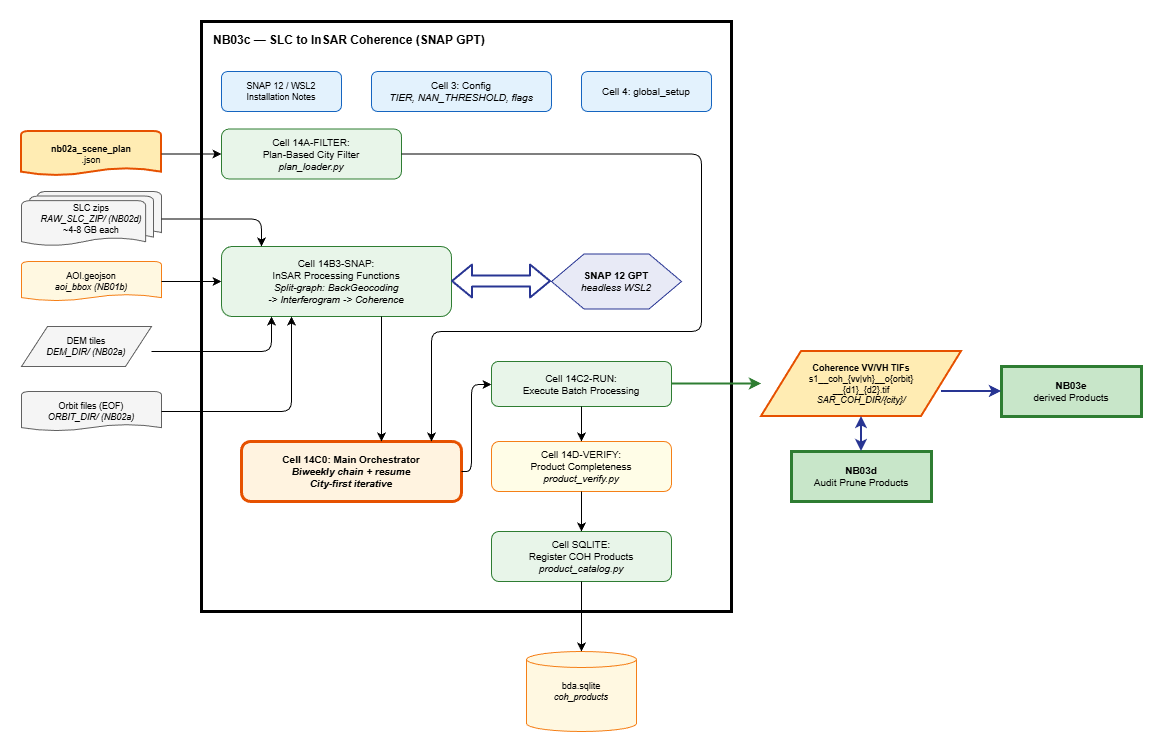

# ESA SNAP 12 Installation on WSL2 Ubuntu

## Overview
ESA SNAP (Sentinel Application Platform) v12.0.0 installed on WSL2 Ubuntu for headless Sentinel-1 SLC processing via GPT (Graph Processing Tool). **Downgraded from SNAP 13** due to multiple InSAR-breaking regressions (SNAP-4106 CreateStack NPE, SNAP-4150 Cross-Correlation null string, TC blank output).

## Why SNAP 12 over SNAP 13
- SNAP 13 TOPSAR-Split silently resets subswath to IW1 (fixed in 13.0.2 but other bugs remain)
- SNAP 13 CreateStack throws NullPointerException on mixed-unit band stacks (SNAP-4106, still open Feb 2026)
- SNAP 13 Cross-Correlation fails with "Cannot parse null string" (SNAP-4150, still open Feb 2026)
- SNAP 13 Terrain Correction produces blank output for some S1 products
- Multiple STEP Forum users confirmed SNAP 12 resolves all these issues

## Prerequisites
- WSL2 Ubuntu 24.04
- Conda environment: `bda` at `/home/alpineobotics/miniconda3/envs/bda/`
- Java (bundled with SNAP installer)

## 1. Download & Install

```bash
cd ~
wget https://download.esa.int/step/snap/12.0/installers/esa-snap_all_linux-12.0.0.sh
chmod +x esa-snap_all_linux-12.0.0.sh
./esa-snap_all_linux-12.0.0.sh -c
```

**Installer prompts:**
- **Install directory:** `~/esa-snap`
- **Python executable:** `/home/alpineobotics/miniconda3/envs/bda/bin/python`
- **Symlinks:** default

## 2. GPT Anti-Hang Configuration

The split-graph pipeline in Cell 14B3 passes flags directly via command line (GPT ignores snap.properties).
Key flags set in `GPT_FLAGS`:
```
-x          # Clear tile cache after each row (prevents eviction cascade)
-c 30G      # Tile cache (reduced) = ~63% of Xmx
-q 2        # Limit threads (reduced from 4) (BackGeocoding conflicts with high parallelism)
-J-Xmx48G  # JVM heap (reduced from 64G)
-J-Xms2G   # Initial heap
-e          # Show stack traces on error
```

`gpt.vmoptions` baseline:
```
-Xmx64G
```

## 3. Verification

| Test | Command | Expected Result |
|------|---------|-----------------|
| CLI help | `~/esa-snap/bin/gpt -h 2>&1 \| head -5` | SNAP GPT help header |
| Diagnostics | `~/esa-snap/bin/gpt --diag` | Shows tile cache, parallelism, JVM memory |
| Operators | `~/esa-snap/bin/gpt -h` | Long list of operators |

## 4. Graph Splitting Strategy (Cell 14B3)

Single monolithic graph hangs because tile cache eviction cascades through the full operator chain.
Split into 3 separate GPT calls with BEAM-DIMAP intermediates:

**Step 1** (per scene): Read -> TOPSAR-Split -> Apply-Orbit -> Write [BEAM-DIMAP]
**Step 2** (pair): Read(master) + Read(slave) -> BackGeocoding -> Interferogram -> Deburst -> Write [BEAM-DIMAP]
**Step 3** (isolated): Read -> Terrain-Correction -> Write [BEAM-DIMAP]
**Step 4** (Python/rasterio): Read .img bands from .data dir -> clip to city -> Write GeoTIFF (EPSG:4326)

Terrain Correction MUST be isolated because its spatial resampling pattern conflicts with InSAR chain tile access.

## 5. I/O Strategy

All SNAP processing on native WSL2 ext4 filesystem (`/home/alpineobotics/snap_work/`).
drvfs mounts (`/mnt/c/`, `/content/drive/`) impose 10-30x I/O penalty for tile-based processing.
Only final clipped GeoTIFFs written to mounted drive (`SAR_SLC_DIR`).

## Notes
- Installation date: 2026-02-15
- Replaces SNAP 13.0.0 (installed 2025-02-14)
- DEM cache at `~/.snap/auxdata/dem/` preserved across reinstall


# CELL 4: COMPLETE ENVIRONMENT SETUP (BDA + SNAP12) - LOCAL WSL VERSION


In [1]:
# @title CELL 3: NB03a CONFIG
# ---- shared ----
TIER_SELECTION = [0,1,2,3]
CITY_SELECTION = None            # or ["Mariupol"]
REQUIRE_SAR_ALIGNED = False
FORCE_RERUN = False
OVERWRITE_EXISTING_TIFS = False
DELETE_OLD_PRODUCTS = False
DELETE_ZIPS_AFTER_EXTRACT = False

# ---- pre-audit (cell 7) ----
NAN_THRESHOLD = 0.90
MIN_FILE_BYTES = 1024
BBOX_TOLERANCE = 0.001
RASTERIO_SAMPLE_PER_CITY = 3
# ---- SNAP processing (cell 25) ----
VAR_COH_WIN_AZ = 2
VAR_COH_WIN_RG = 3
VAR_PIXEL_SPACING = 10
# ---- orchestrator (cell 27) ----
MAX_ORBIT_RETRIES = 3
MAX_SCENE_RETRIES = 15
DEFAULT_ORBITS = [43, 94, 21, 123, 65, 36, 87, 14, 116, 138]
KEEP_SCENES_IN_TEMP = True
MIN_SLC_SIZE = 3e9
# ---- run (cell 29) ----
TARGET_CITY = CITY_SELECTION
STOP_ON_FAILURE = False
MAX_CITIES = None
FIX_TRACKER = True
RESET_TRACKER = False
REPAIR_TRACKER = True
RESUME_FROM_TEMP = True
CLEAR_TEMP_BEFORE = True
# ---- verify (cell 35) ----
MIN_SLC_COHERENCE_FILES = 2
MIN_CARD_FILES_PER_SCENE = 2
MIN_MS_BANDS_PER_SCENE = 12

DEM_BUFFER = 0.15
MIN_SLC_SIZE = 3e9
MIN_CARD_SIZE = 1e9
REQUIRE_SAR_ALIGNED = True
SHORT_CONFLICT_THRESHOLD_DAYS = 30
# @title CELL CONFIG: NB03e
CLIP_BY_POLYGON = False
DRY_RUN_PRUNE = False
PRUNE_SELECTOR = ['superseded_coh', 'stale_date', 'wrong_extent', 'surplus_city', 'corrupt']  # or 'ALL'
VERBOSE = True

In [2]:
# @title CELL 4: LOAD GLOBAL SETUP
import platform, os
if platform.system() == 'Windows':
    _setup = r'F:\PROJECTS\masterthesis\gdrive\masterthesis\notebooks\global_setup.py'
elif os.path.exists('/content/drive_f'):
    _setup = '/content/drive_f/masterthesis/notebooks/global_setup.py'
else:
    _setup = '/mnt/f/PROJECTS/masterthesis/gdrive/masterthesis/notebooks/global_setup.py'
with open(_setup) as f:
    exec(f.read())

/home/alpineobotics/miniconda3/envs/bda/lib/python3.12/site-packages/pyproj/network.py:59: UserWarning: pyproj unable to set PROJ database path.
  _set_context_ca_bundle_path(ca_bundle_path)


BDA GLOBAL SETUP
Started: 2026-04-22 19:07:05
Python: 3.12.12

[1/7] Directory Structure
----------------------------------------------------------------------
  GDrive (G:):       /content/drive_f/masterthesis OK
  GDrive (F:):       /content/drive_f/masterthesis OK
  Local data (G:):   /content/masterthesis_local/data OK
  Data stack (F:):   /mnt/f/PROJECTS/masterthesis/data_stack OK

  TIER_SELECTION: [0, 1, 2, 3]
  CITY_SELECTION: None (tier filter)
  REQUIRE_UNOSAT: False
  CITIES_TO_PROCESS: 31 cities

[2/7] Credentials
----------------------------------------------------------------------
  Copernicus: inf***
  OpenTopography: OK
  Earthdata: marcoheinzen

[3/7] Python Packages
----------------------------------------------------------------------


<string>:564: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.



  Already installed: 23
  Newly installed:   0
  Failed:            0

[4/7] Global Imports & Configuration
----------------------------------------------------------------------
  All imports loaded

[5/7] Processing Config & SNAP
----------------------------------------------------------------------
  GPT: Usage:
  Temporal baseline: 10-24 days
  Wavelength: 0.0555

[6/7] GPU Status
----------------------------------------------------------------------
  CUDA available: NVIDIA GeForce RTX 2070 SUPER
    CUDA version: 12.8

[7/7] Disk Space
----------------------------------------------------------------------
  GDrive (G:)     910.0/7452.0 GB (6542.1 GB free)
  GDrive (F:)     1208.4/3726.0 GB (2517.6 GB free)
  Local data      11600.3/14901.9 GB (3301.6 GB free)
  Data stack      1208.4/3726.0 GB (2517.6 GB free)
  WSL ext4        93.4/1006.9 GB (862.2 GB free)

GLOBAL SETUP COMPLETE
  Torch device: cuda
  Cities: 31, CITY=Avdiivka
  Functions: load_aoi(), load_aoi_gdf(), load_aoi_

# CELL 14A-FILTER: PLAN-BASED CITY FILTER


In [3]:
# @title CELL 14A-FILTER: TIER SELECTION FILTER (PLAN-BASED)
# Replaces old tier_filter.run() that needed cities_df from scene loader.
# Reads plan + AOI.geojson -> same output variables as old tier filter.
# Outputs: cities_df_filtered, ms_cities_df_filtered,
#          SAR_CITIES_TO_PROCESS, MS_CITIES_TO_PROCESS, CITIES_TO_PROCESS

import sys, importlib
if str(NOTEBOOKS_DIR) not in sys.path:
    sys.path.insert(0, str(NOTEBOOKS_DIR))

import pandas as pd
import plan_loader
importlib.reload(plan_loader)
plan_loader.init(OUTPUTS_DIR, RAW_SLC_ZIP, MIN_SLC_SIZE, cities_dir=CITIES_DIR)
plan = plan_loader.load_plan()

print("=" * 80)
print("CELL 14A-FILTER: TIER SELECTION FILTER (PLAN-BASED)")
print("=" * 80)

# ============================================================================
# BUILD CITY DATAFRAMES FROM PLAN + AOI
# ============================================================================

def _classify(date_str, battle_start, battle_stop):
    if battle_start and date_str >= battle_start:
        if battle_stop and date_str > battle_stop:
            return "post"
        return "battle"
    return "pre"

sar_rows = []
ms_rows = []

for city_name, cp in sorted(plan.items()):
    # City metadata from AOI.geojson (master)
    try:
        info = plan_loader.get_city_info(city_name)
        tier = info.get('tier')
        oblast = info.get('oblast', '')
        battle_start = info.get('battle_start', '')
        battle_stop = info.get('battle_stop', '')
        if battle_stop == 'ongoing':
            battle_stop = None
    except (FileNotFoundError, ValueError):
        tier = cp.get('tier')
        oblast = ''
        battle_start = cp.get('battle_start', '')
        battle_stop = cp.get('battle_stop', '')

    if tier is None:
        continue
    tier = int(tier)

    bs = str(battle_start)[:10] if battle_start else ''
    be = str(battle_stop)[:10] if battle_stop else ''

    # Classify SLC scenes by period
    slc_list = cp.get('slc', [])
    pre_scenes = [e for e in slc_list if _classify(e.get('date','')[:10], bs, be) == 'pre'
                  and e.get('status') in ('on_disk','extracted','coh_processed')]
    post_scenes = [e for e in slc_list if _classify(e.get('date','')[:10], bs, be) == 'post'
                   and e.get('status') in ('on_disk','extracted','coh_processed')]
    battle_scenes = [e for e in slc_list if _classify(e.get('date','')[:10], bs, be) == 'battle'
                     and e.get('status') in ('on_disk','extracted','coh_processed')]

    sar_rows.append({
        'city': city_name,
        'tier': tier,
        'oblast': oblast,
        'orbit': cp.get('orbit'),
        'orbit_card': cp.get('orbit_card'),
        'battle_start': pd.Timestamp(bs) if bs else pd.NaT,
        'battle_end': pd.Timestamp(be) if be else pd.NaT,
        'pre_scenes': pre_scenes,
        'post_scenes': post_scenes,
        'battle_scenes': battle_scenes,
        'n_slc_plan': len(slc_list),
        'n_card_disk': len([e for e in cp.get('card', []) if e.get('status') in ('on_disk','extracted')]),
        'coh_done': len(cp.get('coh_pairs', [])),
    })

    # MS scenes
    ms_list = cp.get('ms', [])
    ms_pre = [e for e in ms_list if _classify(e.get('date','')[:10], bs, be) == 'pre'
              and e.get('status') in ('on_disk','extracted')]
    ms_post = [e for e in ms_list if _classify(e.get('date','')[:10], bs, be) == 'post'
               and e.get('status') in ('on_disk','extracted')]
    ms_battle = [e for e in ms_list if _classify(e.get('date','')[:10], bs, be) == 'battle'
                 and e.get('status') in ('on_disk','extracted')]

    ms_rows.append({
        'city': city_name,
        'tier': tier,
        'oblast': oblast,
        'battle_start': pd.Timestamp(bs) if bs else pd.NaT,
        'battle_end': pd.Timestamp(be) if be else pd.NaT,
        'pre_scenes': ms_pre,
        'post_scenes': ms_post,
        'battle_scenes': ms_battle,
    })

cities_df = pd.DataFrame(sar_rows)
ms_cities_df = pd.DataFrame(ms_rows)

print(f"\nSource dataframes:")
print(f"  cities_df (SAR):    {len(cities_df)} cities")
print(f"  ms_cities_df (MS):  {len(ms_cities_df)} cities")

# ============================================================================
# FILTER
# ============================================================================
print(f"\nFILTER CONFIGURATION:")
print(f"  TIER_SELECTION:     {TIER_SELECTION}")
print(f"  CITY_SELECTION:     {CITY_SELECTION}")

sar_filtered = cities_df.copy()
ms_filtered = ms_cities_df.copy()

if TIER_SELECTION and TIER_SELECTION != "ALL":
    sar_filtered = sar_filtered[sar_filtered['tier'].isin(TIER_SELECTION)]
    ms_filtered = ms_filtered[ms_filtered['tier'].isin(TIER_SELECTION)]

if CITY_SELECTION is not None:
    sar_filtered = sar_filtered[sar_filtered['city'].isin(CITY_SELECTION)]
    ms_filtered = ms_filtered[ms_filtered['city'].isin(CITY_SELECTION)]

sar_filtered = sar_filtered.sort_values(['tier', 'city']).reset_index(drop=True)
ms_filtered = ms_filtered.sort_values(['tier', 'city']).reset_index(drop=True)

# ============================================================================
# OUTPUT VARIABLES (same as old tier_filter.run())
# ============================================================================
cities_df_filtered = sar_filtered
ms_cities_df_filtered = ms_filtered

SAR_CITIES_TO_PROCESS = cities_df_filtered['city'].tolist()
MS_CITIES_TO_PROCESS = ms_cities_df_filtered['city'].tolist()
CITIES_TO_PROCESS = sorted(set(SAR_CITIES_TO_PROCESS) & set(MS_CITIES_TO_PROCESS))

# ============================================================================
# SUMMARY
# ============================================================================
print(f"\n{'='*80}")
print("FILTER RESULTS")
print(f"{'='*80}")

print(f"\nSAR cities to process: {len(SAR_CITIES_TO_PROCESS)}")
print(f"MS cities to process:  {len(MS_CITIES_TO_PROCESS)}")
print(f"Cities in BOTH:        {len(CITIES_TO_PROCESS)}")

print(f"\nTier breakdown (filtered):")
if len(cities_df_filtered) > 0:
    for tier, group in cities_df_filtered.groupby('tier'):
        ms_count = len(ms_filtered[ms_filtered['tier'] == tier])
        print(f"  Tier {tier}: {len(group)} SAR, {ms_count} MS")

print(f"\n{'='*80}")
print("CITIES TO PROCESS:")
print(f"{'='*80}")

for idx, city in enumerate(CITIES_TO_PROCESS, 1):
    sar_row = cities_df_filtered[cities_df_filtered['city'] == city].iloc[0]
    ms_row = ms_cities_df_filtered[ms_cities_df_filtered['city'] == city].iloc[0]

    tier = sar_row['tier']
    battle_end_str = sar_row['battle_end'].date() if pd.notna(sar_row['battle_end']) else 'ongoing'
    battle_start_str = sar_row['battle_start'].date() if pd.notna(sar_row['battle_start']) else '?'

    sar_pre = len(sar_row['pre_scenes'])
    sar_post = len(sar_row['post_scenes'])
    sar_battle = len(sar_row.get('battle_scenes', []))
    ms_pre = len(ms_row['pre_scenes'])
    ms_post = len(ms_row['post_scenes'])
    ms_battle = len(ms_row.get('battle_scenes', []))

    sar_str = f"{sar_pre}+{sar_post}"
    if sar_battle:
        sar_str += f"+{sar_battle}b"
    ms_str = f"{ms_pre}+{ms_post}"
    if ms_battle:
        ms_str += f"+{ms_battle}b"

    print(f"  {idx:2d}. [T{tier}] {city:<20} | SAR: {sar_str} | MS: {ms_str} | {battle_start_str} - {battle_end_str}")

print(f"\n{'='*80}")
print("EXPORTED VARIABLES")
print(f"{'='*80}")
print(f"  cities_df_filtered     - SAR dataframe ({len(cities_df_filtered)} cities)")
print(f"  ms_cities_df_filtered  - MS dataframe ({len(ms_cities_df_filtered)} cities)")
print(f"  SAR_CITIES_TO_PROCESS  - List of {len(SAR_CITIES_TO_PROCESS)} SAR city names")
print(f"  MS_CITIES_TO_PROCESS   - List of {len(MS_CITIES_TO_PROCESS)} MS city names")
print(f"  CITIES_TO_PROCESS      - List of {len(CITIES_TO_PROCESS)} cities in BOTH")


  Plan loaded: 50 cities from nb02a_scene_plan.json
CELL 14A-FILTER: TIER SELECTION FILTER (PLAN-BASED)

Source dataframes:
  cities_df (SAR):    50 cities
  ms_cities_df (MS):  50 cities

FILTER CONFIGURATION:
  TIER_SELECTION:     [0, 1, 2, 3]
  CITY_SELECTION:     None

FILTER RESULTS

SAR cities to process: 31
MS cities to process:  31
Cities in BOTH:        31

Tier breakdown (filtered):
  Tier 0: 4 SAR, 4 MS
  Tier 1: 11 SAR, 11 MS
  Tier 2: 6 SAR, 6 MS
  Tier 3: 10 SAR, 10 MS

CITIES TO PROCESS:
   1. [T2] Avdiivka             | SAR: 5+2+58b | MS: 7+5+16b | 2022-02-24 - 2024-02-17
   2. [T3] Bakhmut              | SAR: 5+2+31b | MS: 8+6+7b | 2022-05-17 - 2023-05-20
   3. [T3] Balakliia            | SAR: 5+2+16b | MS: 8+7+22b | 2022-03-03 - 2022-09-08
   4. [T1] Borodyanka           | SAR: 5+2+3b | MS: 0+0 | 2022-02-28 - 2022-04-01
   5. [T1] Bucha                | SAR: 5+2+2b | MS: 7+4+3b | 2022-02-27 - 2022-03-31
   6. [T1] Chernihiv            | SAR: 2+0 | MS: 7+7+3b | 2022-02

# CELL 14B3: INSAR PROCESSING FUNCTIONS (SNAP GPT - SPLIT GRAPH + GDAL)

Split-graph pipeline: 3 separate GPT calls with BEAM-DIMAP intermediates

All SNAP processing on native WSL2 ext4 filesystem (not drvfs)

Anti-hang flags: -x -c 40G -q 4 -J-Xmx64G

Final output: GeoTIFF via rasterio, clipped to city, EPSG:4326


In [4]:
# @title CELL 14B3-SNAP: INSAR PROCESSING FUNCTIONS (SNAP GPT - SPLIT GRAPH + GDAL)
CELL_ID = "cell_14b3_snap_processing"

print("\n" + "=" * 80)
print("CELL 14B3-SNAP: INSAR PROCESSING FUNCTIONS (SNAP GPT - SPLIT GRAPH)")
print("=" * 80)

import os
import json
import time
import shutil
import subprocess
import tempfile
from pathlib import Path
from datetime import datetime, timedelta
import numpy as np
import rasterio
import rasterio.mask
import rasterio.transform
import geopandas as gpd
from shapely.geometry import box, mapping
from bonus_city_filter import load_city_dates, is_date_in_range

# =============================================================================
# SNAP CONFIGURATION
# =============================================================================
GPT_PATH = os.path.expanduser("~/esa-snap/bin/gpt")
SNAP_GRAPH_DIR = Path("/content/drive/MyDrive/masterthesis/snap_graphs")
SNAP_GRAPH_DIR.mkdir(parents=True, exist_ok=True)

# Native WSL2 filesystem for ALL SNAP processing (no drvfs!)
# drvfs (/mnt/c, /mnt/d, /content/drive) is 10-30x slower for tile I/O
SNAP_WORK_ROOT = Path("/home/alpineobotics/snap_work")
SNAP_WORK_ROOT.mkdir(parents=True, exist_ok=True)

# Final outputs go to mounted Windows drive (for Google Drive sync / GPU access)
# SAR_SLC_DIR is defined in Cell 4 as DATA_ROOT / 'satellite' / 'SAR_SLC'

# GPT flags - these fix the tile cache recomputation hang
# -x : clear tile cache after each row (prevents eviction cascade)
# -c 30G : tile cache (reduced) = ~63% of Xmx (sweet spot per SNAP devs)
# -q 2 : limit threads to 2 (reduced from 4, each GPT ~35-48GB)
# -J-Xmx48G : JVM heap (reduced from 64G to coexist with other notebooks)
# -e : show stack traces on error
GPT_FLAGS = [
    "-x",
    "-c", "30G",
    "-q", "2",
    "-J-Xmx48G",
    "-J-Xms2G",
    "-e",
    "-J-Dsnap.log.level=WARNING",
]

# Verify GPT
if not os.path.exists(GPT_PATH):
    print(f"  WARNING: GPT not found at {GPT_PATH}")
    print(f"  Install SNAP or update GPT_PATH")
else:
    result = subprocess.run([GPT_PATH, "-h"], capture_output=True, text=True, timeout=30)
    first_line = result.stdout.strip().split('\n')[0] if result.stdout else 'OK'
    print(f"  GPT: {first_line}")

print(f"  SNAP_WORK_ROOT: {SNAP_WORK_ROOT} (native ext4)")
print(f"  GPT flags: {' '.join(GPT_FLAGS)}")

# Load battle dates for bonus city temporal filtering (+-14 months)
_bonus_city_dates = load_city_dates(CITIES_DIR)
print(f"  Bonus city dates: {len(_bonus_city_dates)} cities loaded")

# =============================================================================
# GRAPH GENERATION - SPLIT INTO 3 STEPS
# =============================================================================
# Step 1: Read + Split + Orbit (per scene) -> BEAM-DIMAP
# Step 2: BackGeocoding + Interferogram + Deburst -> BEAM-DIMAP
# Step 3: Terrain Correction -> BEAM-DIMAP
# Step 4: GDAL convert .img bands to GeoTIFF (EPSG:4326)
# =============================================================================

def generate_graph_step1(scene_path, subswath, output_dim_path, wkt_aoi=None):
    """Graph Step 1: Read -> TOPSAR-Split -> Apply-Orbit-File -> Write BEAM-DIMAP
    Run once per scene (master + slave separately)."""

    wkt_param = f"\n      <wktAoi>{wkt_aoi}</wktAoi>" if wkt_aoi else ""

    graph = f"""<graph id="s1_step1_split_orbit">
  <version>1.0</version>

  <node id="Read">
    <operator>Read</operator>
    <sources/>
    <parameters><file>{scene_path}</file></parameters>
  </node>

  <node id="Split">
    <operator>TOPSAR-Split</operator>
    <sources><sourceProduct refid="Read"/></sources>
    <parameters>
      <subswath>{subswath}</subswath>
      <selectedPolarisations>VV,VH</selectedPolarisations>{wkt_param}
    </parameters>
  </node>

  <node id="Orbit">
    <operator>Apply-Orbit-File</operator>
    <sources><sourceProduct refid="Split"/></sources>
    <parameters>
      <orbitType>Sentinel Precise (Auto Download)</orbitType>
      <polyDegree>3</polyDegree>
      <continueOnFail>true</continueOnFail>
    </parameters>
  </node>

  <node id="Write">
    <operator>Write</operator>
    <sources><sourceProduct refid="Orbit"/></sources>
    <parameters>
      <file>{output_dim_path}</file>
      <formatName>BEAM-DIMAP</formatName>
    </parameters>
  </node>

</graph>"""
    return graph


def generate_graph_step2(master_dim_path, slave_dim_path, output_dim_path,
                         coh_win_az, coh_win_rg):
    """Graph Step 2: BackGeocoding -> Interferogram (with coherence) -> Deburst -> Write BEAM-DIMAP
    Takes two Split+Orbit products as input."""

    graph = f"""<graph id="s1_step2_insar_core">
  <version>1.0</version>

  <node id="Read-Master">
    <operator>Read</operator>
    <sources/>
    <parameters><file>{master_dim_path}</file></parameters>
  </node>

  <node id="Read-Slave">
    <operator>Read</operator>
    <sources/>
    <parameters><file>{slave_dim_path}</file></parameters>
  </node>

  <node id="BackGeo">
    <operator>Back-Geocoding</operator>
    <sources>
      <sourceProduct refid="Read-Master"/>
      <sourceProduct.1 refid="Read-Slave"/>
    </sources>
    <parameters>
      <demName>SRTM 1Sec HGT</demName>
      <demResamplingMethod>BICUBIC_INTERPOLATION</demResamplingMethod>
      <resamplingType>BISINC_5_POINT_INTERPOLATION</resamplingType>
      <maskOutAreaWithoutElevation>true</maskOutAreaWithoutElevation>
      <outputDerampDemodPhase>true</outputDerampDemodPhase>
    </parameters>
  </node>

  <node id="Ifg">
    <operator>Interferogram</operator>
    <sources><sourceProduct refid="BackGeo"/></sources>
    <parameters>
      <subtractFlatEarthPhase>true</subtractFlatEarthPhase>
      <srpPolynomialDegree>5</srpPolynomialDegree>
      <srpNumberPoints>501</srpNumberPoints>
      <orbitDegree>3</orbitDegree>
      <includeCoherence>true</includeCoherence>
      <cohWinAz>{VAR_COH_WIN_AZ}</cohWinAz>
      <cohWinRg>{VAR_COH_WIN_RG}</cohWinRg>
      <squarePixel>true</squarePixel>
      <subtractTopographicPhase>true</subtractTopographicPhase>
      <demName>SRTM 1Sec HGT</demName>
      <tileExtensionPercent>100</tileExtensionPercent>
      <outputElevation>false</outputElevation>
      <outputLatLon>false</outputLatLon>
    </parameters>
  </node>

  <node id="Deburst">
    <operator>TOPSAR-Deburst</operator>
    <sources><sourceProduct refid="Ifg"/></sources>
    <parameters>
      <selectedPolarisations>VV,VH</selectedPolarisations>
    </parameters>
  </node>

  <node id="Write">
    <operator>Write</operator>
    <sources><sourceProduct refid="Deburst"/></sources>
    <parameters>
      <file>{output_dim_path}</file>
      <formatName>BEAM-DIMAP</formatName>
    </parameters>
  </node>

</graph>"""
    return graph


def generate_graph_step3(input_dim_path, output_dim_path, pixel_spacing=VAR_PIXEL_SPACING):
    """Graph Step 3: Terrain Correction -> Write BEAM-DIMAP
    MUST be isolated from InSAR chain to prevent tile cache hang."""

    graph = f"""<graph id="s1_step3_terrain_correction">
  <version>1.0</version>

  <node id="Read">
    <operator>Read</operator>
    <sources/>
    <parameters><file>{input_dim_path}</file></parameters>
  </node>

  <node id="TC">
    <operator>Terrain-Correction</operator>
    <sources><sourceProduct refid="Read"/></sources>
    <parameters>
      <demName>SRTM 1Sec HGT</demName>
      <demResamplingMethod>BICUBIC_INTERPOLATION</demResamplingMethod>
      <imgResamplingMethod>BICUBIC_INTERPOLATION</imgResamplingMethod>
      <pixelSpacingInMeter>{pixel_spacing}</pixelSpacingInMeter>
      <mapProjection>GEOGCS["WGS84(DD)", DATUM["WGS84", SPHEROID["WGS84", 6378137.0, 298.257223563]], PRIMEM["Greenwich", 0.0], UNIT["degree", 0.017453292519943295], AXIS["Geodetic longitude", EAST], AXIS["Geodetic latitude", NORTH]]</mapProjection>
      <saveSelectedSourceBand>true</saveSelectedSourceBand>
      <outputComplex>false</outputComplex>
      <nodataValueAtSea>true</nodataValueAtSea>
    </parameters>
  </node>

  <node id="Write">
    <operator>Write</operator>
    <sources><sourceProduct refid="TC"/></sources>
    <parameters>
      <file>{output_dim_path}</file>
      <formatName>BEAM-DIMAP</formatName>
    </parameters>
  </node>

</graph>"""
    return graph


# =============================================================================
# GPT EXECUTION
# =============================================================================

def kill_stale_gpt():
    """Kill any orphaned SNAP GPT java processes from previous crashed kernels."""
    try:
        result = subprocess.run(
            ['pgrep', '-f', 'snap.*gpt|org.esa.snap'],
            capture_output=True, text=True, timeout=5
        )
        pids = result.stdout.strip().split()
        if pids and pids[0]:
            print(f"    WARNING: Found {len(pids)} stale GPT process(es): {pids}")
            subprocess.run(['pkill', '-9', '-f', 'snap.*gpt|org.esa.snap'], timeout=10)
            time.sleep(2)
            # also kill orphaned java processes from SNAP
            subprocess.run(['pkill', '-9', '-f', 'java.*snap'], capture_output=True, timeout=5)
            time.sleep(1)
            print(f"    Killed stale GPT processes")
    except Exception:
        pass


def _run_gpt_once(cmd, timeout_minutes, step_label):
    """Single GPT execution attempt. Returns elapsed seconds on success, raises on failure."""
    start = time.time()

    proc = subprocess.Popen(
        cmd,
        stdout=subprocess.PIPE,
        stderr=subprocess.STDOUT,
        text=True,
        bufsize=1,
        start_new_session=True,
    )

    output_lines = []
    try:
        for line in proc.stdout:
            line = line.rstrip()
            if line:
                output_lines.append(line)
                if any(kw in line.lower() for kw in ['%', 'done', 'error', 'warning', 'processing', 'writing']):
                    print(f"    GPT: {line[:120]}")
        proc.wait(timeout=timeout_minutes * 60)
    except subprocess.TimeoutExpired:
        import os, signal
        os.killpg(os.getpgid(proc.pid), signal.SIGKILL)
        proc.wait()
        raise RuntimeError(f"GPT timed out after {timeout_minutes} minutes ({step_label})")
    except Exception:
        proc.kill()
        proc.wait()
        raise
    finally:
        if proc.stdout:
            proc.stdout.close()

    elapsed = time.time() - start
    if proc.returncode != 0:
        print(f"    GPT FAILED {step_label} (exit code {proc.returncode})")
        for line in output_lines[-30:]:
            print(f"    > {line}")
        raise RuntimeError(f"GPT failed {step_label} with exit code {proc.returncode}")

    return elapsed


def run_gpt(graph_xml_path, timeout_minutes=120, step_label="", max_retries=2):
    """Run SNAP GPT with a processing graph using anti-hang flags.
    Kills orphaned GPT processes before launching. On errno 12 (OOM) or
    Java OutOfMemoryError: aggressively kills all Java/SNAP processes,
    waits for memory to free, retries up to max_retries times.
    """
    cmd = [GPT_PATH, str(graph_xml_path)] + GPT_FLAGS

    for attempt in range(1, max_retries + 1):
        kill_stale_gpt()

        print(f"    Running GPT {step_label}: {Path(graph_xml_path).name}" +
              (f" (attempt {attempt}/{max_retries})" if attempt > 1 else ""))

        try:
            elapsed = _run_gpt_once(cmd, timeout_minutes, step_label)
            print(f"    GPT {step_label} completed in {elapsed/60:.1f} minutes")
            return elapsed

        except OSError as e:
            if e.errno == 12 or 'Cannot allocate memory' in str(e):
                print(f"    ERRNO 12 (OOM) on attempt {attempt}/{max_retries}: {e}")
                print(f"    Killing ALL Java/SNAP processes and waiting for memory...")
                for pattern in ['java', 'snap.*gpt', 'org.esa.snap']:
                    try:
                        subprocess.run(['pkill', '-9', '-f', pattern], capture_output=True, timeout=5)
                    except Exception:
                        pass
                wait_secs = 30 * attempt
                print(f"    Waiting {wait_secs}s for memory to free...")
                time.sleep(wait_secs)
                if attempt == max_retries:
                    raise RuntimeError(f"GPT {step_label} failed with errno 12 (OOM) after {max_retries} attempts")
                continue
            else:
                raise

        except RuntimeError as e:
            err_str = str(e).lower()
            if 'errno 12' in err_str or 'cannot allocate memory' in err_str or 'outofmemoryerror' in err_str:
                print(f"    Memory error in GPT output on attempt {attempt}/{max_retries}")
                for pattern in ['java', 'snap.*gpt', 'org.esa.snap']:
                    try:
                        subprocess.run(['pkill', '-9', '-f', pattern], capture_output=True, timeout=5)
                    except Exception:
                        pass
                wait_secs = 30 * attempt
                print(f"    Waiting {wait_secs}s for memory to free...")
                time.sleep(wait_secs)
                if attempt == max_retries:
                    raise
                continue
            else:
                raise



# =============================================================================
# GDAL CONVERSION: BEAM-DIMAP .img -> GeoTIFF (EPSG:4326)
# =============================================================================

def convert_dimap_to_geotiffs(dimap_data_dir, output_dir, city_name, city_geom,
                              dates_str, output_subdir, orbit=None, period_label=None):
    """Convert BEAM-DIMAP .img bands to individual GeoTIFFs clipped to city boundary.

    BEAM-DIMAP stores each band as an ENVI .img file in the .data directory.
    We use rasterio to read them (ENVI driver) and clip to city bounds.

    The TC step already geocodes to EPSG:4326, so .img files are already in WGS84.
    We just read, clip, and write as compressed GeoTIFF.

    Produces same filenames as the old pipeline for downstream compatibility.
    """
    city_output_dir = output_dir / city_name
    city_output_dir.mkdir(parents=True, exist_ok=True)

    date_str_t0 = dates_str[0]
    date_str_t1 = dates_str[1]
    pair_str = f"{date_str_t0}_{date_str_t1}"
    orbit_tag = f"__o{orbit:03d}" if orbit else ""

    # clip to aoi_bbox (256-aligned rectangle) from AOI.geojson
    aoi_bbox_geom = load_aoi_bbox(city_name, CITIES_DIR)
    shapes = [mapping(aoi_bbox_geom)]
    exported_files = {}

    dimap_data_dir = Path(dimap_data_dir)
    img_files = sorted(dimap_data_dir.glob("*.img"))

    if not img_files:
        print(f"    WARNING: No .img files found in {dimap_data_dir}")
        return exported_files, 0, 0

    print(f"    Found {len(img_files)} .img bands in {dimap_data_dir.name}")

    clip_h, clip_w = 0, 0

    for img_file in img_files:
        bname = img_file.stem.lower()

        # Map SNAP band names to our product naming convention
        # SNAP names look like: coh_IW2_VV_22Feb2022_06Mar2022, i_ifg_IW2_VV_..., Intensity_IW2_VV_...
        if '_vv_' in bname or bname.startswith('vv') or '_vv' in bname:
            pol = 'VV'
        elif '_vh_' in bname or bname.startswith('vh') or '_vh' in bname:
            pol = 'VH'
        else:
            pol = ''

        if 'coh' in bname:
            product_name = f"s1__coh_{pol.lower()}{orbit_tag}__{pair_str}" if pol else f"s1__coh{orbit_tag}__{pair_str}"
        elif 'i_ifg' in bname:
            product_name = f"s1__ifg_real_{pol.lower()}{orbit_tag}__{pair_str}" if pol else f"s1__ifg_real{orbit_tag}__{pair_str}"
        elif 'q_ifg' in bname:
            product_name = f"s1__ifg_imag_{pol.lower()}{orbit_tag}__{pair_str}" if pol else f"s1__ifg_imag{orbit_tag}__{pair_str}"
        elif 'intensity' in bname and ('mst' in bname or 'ref' in bname):
            product_name = f"s1__int_{pol.lower()}{orbit_tag}__{date_str_t0}" if pol else f"s1__int{orbit_tag}__{date_str_t0}"
        elif 'intensity' in bname and ('slv' in bname or 'sec' in bname):
            product_name = f"s1__int_{pol.lower()}{orbit_tag}__{date_str_t1}" if pol else f"s1__int{orbit_tag}__{date_str_t1}"
        elif 'phase' in bname:
            product_name = f"s1__phs_{pol.lower()}{orbit_tag}__{pair_str}" if pol else f"s1__phs{orbit_tag}__{pair_str}"
        else:
            product_name = f"band_{img_file.stem}"
            print(f"      Skipping non-essential band: {img_file.stem}")
            continue

        try:
            with rasterio.open(img_file) as src:
                # BEAM-DIMAP .img after TC should already be EPSG:4326
                # but ENVI .hdr might not have CRS - force it
                src_crs = src.crs if src.crs else rasterio.CRS.from_epsg(4326)

                clipped, clip_transform = rasterio.mask.mask(
                    src, shapes, crop=True, nodata=0, all_touched=True
                )
                clip_h, clip_w = clipped.shape[1], clipped.shape[2]
                data = clipped[0]

                # Replace 0 with NaN for float products
                data = data.astype(np.float32)
                data[data == 0] = np.nan

                # Convert intensity to dB
                if 'intensity' in product_name:
                    with np.errstate(divide='ignore', invalid='ignore'):
                        data = np.where(data > 0, 10 * np.log10(data), np.nan)

                output_path = city_output_dir / f"{product_name}.tif"

                with rasterio.open(
                    output_path, 'w',
                    driver='GTiff',
                    height=clip_h,
                    width=clip_w,
                    count=1,
                    dtype=np.float32,
                    crs='EPSG:4326',
                    transform=clip_transform,
                    compress='lzw',
                    nodata=np.nan
                ) as dst:
                    dst.write(data, 1)
                    dst.set_band_description(1, product_name)

                exported_files[f"{product_name}.tif"] = str(output_path)
                print(f"      Exported: {product_name}.tif")

        except Exception as e:
            print(f"      WARNING: Failed to convert {img_file.name}: {e}")
            continue

    return exported_files, clip_h, clip_w


# =============================================================================
# SUBSWATH DETECTION (unchanged)
# =============================================================================

def detect_best_subswath(scene_path, city_geom):
    """Detect which IW subswath best covers the city using annotation XMLs."""
    import xml.etree.ElementTree as ET
    from shapely.geometry import Polygon
    from shapely.wkt import loads

    manifest = Path(scene_path) / "manifest.safe"
    if not manifest.exists():
        print(f"    WARNING: manifest.safe not found, defaulting to IW2")
        return "IW2"

    tree = ET.parse(manifest)
    root = tree.getroot()
    ns = {'safe': 'http://www.esa.int/safe/sentinel/1.1',
          'gml': 'http://www.opengis.net/gml'}

    best_sw = "IW2"
    best_coverage = 0

    annotation_dir = Path(scene_path) / "annotation"
    if annotation_dir.exists():
        for iw in [1, 2, 3]:
            pattern = f"*-iw{iw}-*-vv-*.xml"
            ann_files = list(annotation_dir.glob(pattern))
            if not ann_files:
                continue
            try:
                ann_tree = ET.parse(ann_files[0])
                ann_root = ann_tree.getroot()
                gcps = ann_root.findall('.//geolocationGridPoint')
                if gcps:
                    lats = [float(g.find('latitude').text) for g in gcps]
                    lons = [float(g.find('longitude').text) for g in gcps]
                    sw_box = box(min(lons), min(lats), max(lons), max(lats))
                    if sw_box.intersects(city_geom):
                        coverage = sw_box.intersection(city_geom).area / city_geom.area * 100
                        print(f"    IW{iw}: {coverage:.1f}% coverage")
                        if coverage > best_coverage:
                            best_coverage = coverage
                            best_sw = f"IW{iw}"
            except Exception as e:
                print(f"    IW{iw}: parse error ({e})")

    print(f"    Selected {best_sw} ({best_coverage:.1f}% coverage)")
    return best_sw


# =============================================================================
# MAIN PROCESSING FUNCTION - SPLIT GRAPH PIPELINE
# =============================================================================


def _extract_relative_orbit(scene_name):
    """Extract relative orbit from SLC scene name.
    S1A_IW_SLC__1SDV_20220604T..._20220604T..._043515_053214_53EF.SAFE
    -> abs_orbit=043515 -> rel_orbit via S1A/B/C formula.
    """
    import re as _re
    m = _re.search(r"(S1[ABC])_IW_SLC.*?_(\d{8})T\d{6}_\d{8}T\d{6}_(\d{6})_", str(scene_name))
    if not m:
        return None
    sat = m.group(1)
    abs_orbit = int(m.group(3))
    if sat == "S1B":
        return ((abs_orbit - 27) % 175) + 1
    return ((abs_orbit - 73) % 175) + 1

def process_insar_pair(scene1_path, scene2_path, target_city, output_subdir,
                       basedir=None, apply_speckle_filter=True, speckle_size=5,
                       process_bonus_cities=True, create_viz=True):
    """
    Process an InSAR pair using SNAP GPT split-graph pipeline.
    3 separate GPT calls with BEAM-DIMAP intermediates on native ext4.
    Final conversion via rasterio (reads ENVI .img from BEAM-DIMAP .data dir).

    Args:
        scene1_path: Path to first .SAFE directory
        scene2_path: Path to second .SAFE directory
        target_city: Primary city name to process
        output_subdir: 'prebattle', 'postbattle', or 'crossbattle'
        basedir: Not used (kept for API compatibility)
        apply_speckle_filter: Not used (kept for API compatibility)
        speckle_size: Not used (kept for API compatibility)
        process_bonus_cities: Whether to also export products for other covered cities
        create_viz: Not used (kept for API compatibility)

    Returns:
        dict with status, products, coverage info, bonus cities
    """
    total_start = time.time()

    def print_elapsed(label, start):
        elapsed = time.time() - start
        total = time.time() - total_start
        m, s = divmod(int(elapsed), 60)
        tm, ts = divmod(int(total), 60)
        print(f"    [{m}:{s:02d}] {label} (Total: {tm}:{ts:02d})")

    scene1_path = Path(scene1_path)
    scene2_path = Path(scene2_path)

    # Clean desktop.ini files from SAFE dirs (Google Drive artifacts break SNAP)
    for safe_dir in [scene1_path, scene2_path]:
        for ini in Path(safe_dir).rglob('desktop.ini'):
            ini.unlink()

    # All SNAP work on native ext4 filesystem - NOT drvfs!
    workdir = SNAP_WORK_ROOT / f"{target_city}_{output_subdir}"
    if workdir.exists():
        shutil.rmtree(workdir)
    workdir.mkdir(parents=True, exist_ok=True)

    # Extract dates from scene names early for result dict
    _d1 = scene1_path.name.split('_')[5][:8]
    _d2 = scene2_path.name.split('_')[5][:8]
    _dates_sorted = sorted([
        f"{_d1[:4]}-{_d1[4:6]}-{_d1[6:8]}",
        f"{_d2[:4]}-{_d2[4:6]}-{_d2[6:8]}"
    ])

    result = {
        'status': 'pending',
        'target_city': target_city,
        'output_subdir': output_subdir,
        'scenes': [scene1_path.name, scene2_path.name],
        'dates': _dates_sorted,
        'products': {},
        'bonus_cities': {}
    }

    print("\n" + "=" * 80)
    print("PROCESSING INSAR PAIR (SNAP GPT - SPLIT GRAPH)")
    print("=" * 80)
    print(f"  Target city:     {target_city}")
    print(f"  Output:          {output_subdir}")
    print(f"  Scene 1:         {scene1_path.name}")
    print(f"  Scene 2:         {scene2_path.name}")
    print(f"  Work dir:        {workdir} (native ext4)")
    print("=" * 80)

    # Step 1: Load city info
    print(f"\n  Step 1: Loading city info...")
    step_start = time.time()
    try:
        aoi_row = load_aoi(target_city)
        city_geom = aoi_row.geometry
    except (FileNotFoundError, ValueError) as e:
        result['status'] = 'failed'
        result['error'] = str(e)
        return result

    # Extract dates from scene names
    date1 = scene1_path.name.split('_')[5][:8]
    date2 = scene2_path.name.split('_')[5][:8]
    dates_str = sorted([date1, date2])
    _rel_orbit = _extract_relative_orbit(scene1_path.name)
    if _rel_orbit:
        print(f"    Relative orbit: {_rel_orbit}")
    print(f"    Dates: {dates_str[0]} / {dates_str[1]}")
    print_elapsed("Load city info", step_start)

    # Step 2: Detect best subswath
    print(f"\n  Step 2: Detecting best subswath...")
    step_start = time.time()
    best_subswath = detect_best_subswath(str(scene1_path), city_geom)
    result['subswath'] = best_subswath
    print_elapsed("Detect subswath", step_start)

    # NO wktAoi - process ALL bursts in subswath for full swath coverage
    # This maximizes spatial extent so bonus cities get covered too
    # Old approach clipped to city AOI which limited coverage to ~31%
    print(f"    Processing full subswath (no burst AOI restriction)")

    # =========================================================================
    # GPT STEP 1: Split + Orbit (per scene, parallel-safe)
    # =========================================================================
    print(f"\n  Step 3a: GPT Split + Orbit (scene 1)...")
    step_start = time.time()

    master_dim = workdir / "master_split_orb"
    slave_dim = workdir / "slave_split_orb"

    graph1a = generate_graph_step1(
        scene_path=str(scene1_path),
        subswath=best_subswath,
        output_dim_path=str(master_dim)
    )
    graph1a_path = workdir / "graph_step1a.xml"
    with open(graph1a_path, 'w') as f:
        f.write(graph1a)

    try:
        run_gpt(graph1a_path, timeout_minutes=30, step_label="Step1a(master)")
    except RuntimeError as e:
        result['status'] = 'failed'
        result['error'] = f'Step1a failed: {e}'
        return result
    print_elapsed("Step 1a (master split+orbit)", step_start)

    print(f"\n  Step 3b: GPT Split + Orbit (scene 2)...")
    step_start = time.time()

    graph1b = generate_graph_step1(
        scene_path=str(scene2_path),
        subswath=best_subswath,
        output_dim_path=str(slave_dim)
    )
    graph1b_path = workdir / "graph_step1b.xml"
    with open(graph1b_path, 'w') as f:
        f.write(graph1b)

    try:
        run_gpt(graph1b_path, timeout_minutes=30, step_label="Step1b(slave)")
    except RuntimeError as e:
        result['status'] = 'failed'
        result['error'] = f'Step1b failed: {e}'
        return result
    print_elapsed("Step 1b (slave split+orbit)", step_start)

    # =========================================================================
    # GPT STEP 2: BackGeocoding + Interferogram + Deburst
    # =========================================================================
    print(f"\n  Step 4: GPT InSAR core (BackGeo + Ifg + Deburst)...")
    step_start = time.time()

    insar_dim = workdir / "insar_deburst"

    graph2 = generate_graph_step2(
        master_dim_path=str(master_dim) + ".dim",
        slave_dim_path=str(slave_dim) + ".dim",
        output_dim_path=str(insar_dim),
        coh_win_az=VAR_COH_WIN_AZ,
        coh_win_rg=VAR_COH_WIN_RG
    )
    
    graph2_path = workdir / "graph_step2.xml"
    with open(graph2_path, 'w') as f:
        f.write(graph2)

    try:
        gpt_elapsed_step2 = run_gpt(graph2_path, timeout_minutes=90, step_label="Step2(InSAR)")
    except RuntimeError as e:
        result['status'] = 'failed'
        result['error'] = f'Step2 failed: {e}'
        return result
    print_elapsed("Step 2 (InSAR core)", step_start)

    # Clean up Step 1 intermediates to save disk
    print(f"    Cleaning Step 1 intermediates...")
    for p in [master_dim.with_suffix('.dim'), slave_dim.with_suffix('.dim')]:
        if p.exists():
            p.unlink()
    for d in [master_dim.with_suffix('.data'), slave_dim.with_suffix('.data')]:
        if d.exists():
            shutil.rmtree(d)

    # =========================================================================
    # GPT STEP 3: Terrain Correction (isolated - prevents hang)
    # =========================================================================
    print(f"\n  Step 5: GPT Terrain Correction (isolated)...")
    step_start = time.time()

    tc_dim = workdir / "tc_output"

    graph3 = generate_graph_step3(
        input_dim_path=str(insar_dim) + ".dim",
        output_dim_path=str(tc_dim),
        pixel_spacing=VAR_PIXEL_SPACING
    )
    graph3_path = workdir / "graph_step3.xml"
    with open(graph3_path, 'w') as f:
        f.write(graph3)

    try:
        gpt_elapsed_step3 = run_gpt(graph3_path, timeout_minutes=60, step_label="Step3(TC)")
    except RuntimeError as e:
        result['status'] = 'failed'
        result['error'] = f'Step3 (TC) failed: {e}'
        return result
    print_elapsed("Step 3 (Terrain Correction)", step_start)

    result['gpt_elapsed_seconds'] = gpt_elapsed_step2 + gpt_elapsed_step3

    # Clean up Step 2 intermediates
    print(f"    Cleaning Step 2 intermediates...")
    insar_dim_file = insar_dim.with_suffix('.dim')
    insar_data_dir = insar_dim.with_suffix('.data')
    if insar_dim_file.exists():
        insar_dim_file.unlink()
    if insar_data_dir.exists():
        shutil.rmtree(insar_data_dir)

    # =========================================================================
    # STEP 4: Convert BEAM-DIMAP -> GeoTIFF via rasterio, clip to city
    # =========================================================================
    print(f"\n  Step 6: Converting BEAM-DIMAP to GeoTIFF + clipping...")
    step_start = time.time()

    tc_data_dir = tc_dim.with_suffix('.data')
    if not tc_data_dir.exists():
        result['status'] = 'failed'
        result['error'] = f'TC output not found: {tc_data_dir}'
        return result

    slc_output_root = SAR_COH_DIR

    # compute period label from dates + battle dates
    from aoi_date_extend_loader import load_city_boundary_with_dates as _lcbwd
    _, _battle_start, _battle_stop, _conflict_ongoing, _ = _lcbwd(target_city, CITIES_DIR)
    try:
        _d0 = datetime.strptime(dates_str[0], '%Y%m%d')
        _d1 = datetime.strptime(dates_str[1], '%Y%m%d')
    except ValueError:
        _d0 = datetime.strptime(dates_str[0], '%Y-%m-%d')
        _d1 = datetime.strptime(dates_str[1], '%Y-%m-%d')
    if _d0 < _battle_start and _d1 < _battle_start:
        period_label = 'PRE'
    elif _battle_stop and _d0 > _battle_stop and _d1 > _battle_stop:
        period_label = 'POST'
    else:
        period_label = 'CROSS'

    all_products, clip_h, clip_w = convert_dimap_to_geotiffs(
        tc_data_dir, slc_output_root, target_city, city_geom, dates_str, output_subdir,
        orbit=_rel_orbit, period_label=period_label
    )
    result['products'] = all_products
    print_elapsed("DIMAP -> GeoTIFF conversion", step_start)

    # Compute coverage stats from VV coherence
    coh_vv_path = None
    for fname in all_products:
        if 'coherence' in fname.lower() and 'VV' in fname.upper():
            coh_vv_path = all_products[fname]
            break

    if coh_vv_path and os.path.exists(coh_vv_path):
        with rasterio.open(coh_vv_path) as src:
            data = src.read(1)
            valid = np.count_nonzero(~np.isnan(data))
            total = data.size
            coverage = 100 * valid / total if total > 0 else 0
            coh_mean = float(np.nanmean(data))
            result['coverage_pct'] = coverage
            result['coherence_vv_mean'] = coh_mean
            print(f"    Coverage: {coverage:.1f}%, VV coherence mean: {coh_mean:.3f}")

    # Step 7: Save metadata
    print(f"\n  Step 7: Saving metadata...")
    city_output_dir = slc_output_root / target_city
    metadata = {
        'city': target_city,
        'period': output_subdir,
        'dates': dates_str,
        'processor': 'SNAP_GPT_12_SPLIT',
        'subswath': best_subswath,
        'pixel_spacing_m': VAR_PIXEL_SPACING,
        'products': list(all_products.keys()),
        'coverage_pct': result.get('coverage_pct', 0),
        'coherence_vv_mean': result.get('coherence_vv_mean', 0),
        'gpt_elapsed_seconds': result.get('gpt_elapsed_seconds', 0),
        'processed_at': datetime.now().isoformat()
    }
    metadata_file = city_output_dir / 'metadata.json'
    with open(metadata_file, 'w') as f:
        json.dump(metadata, f, indent=2)

    # Step 8: Bonus cities (extract from TC output for other cities covered by scene)
    if process_bonus_cities:
        print(f"\n  Step 8: Checking bonus cities...")
        step_start = time.time()

        # Get bounds from one of the .img files
        img_files = list(tc_data_dir.glob("*.img"))
        if img_files:
            with rasterio.open(img_files[0]) as src:
                scene_bounds = box(*src.bounds)

            bonus_count = 0
            bonus_date_skipped = 0
            all_city_dirs = [d for d in CITIES_DIR.iterdir() if d.is_dir() and (d / 'AOI.geojson').exists()]
            for city_dir in all_city_dirs:
                bonus_city = city_dir.name
                if bonus_city == target_city:
                    continue
                # temporal gate: skip if pair date outside bonus city battle window (+-14mo)
                _bs, _be = _bonus_city_dates.get(bonus_city, (None, None))
                if not is_date_in_range(dates_str[0], _bs, _be):
                    bonus_date_skipped += 1
                    continue
                bonus_row = load_aoi(bonus_city)
                bonus_geom = bonus_row.geometry  # city_polygon for overlap check
                try:
                    bonus_clip_geom = load_aoi_bbox(bonus_city, CITIES_DIR)  # aoi_bbox for clipping
                except (FileNotFoundError, ValueError):
                    continue
                if scene_bounds.intersects(bonus_geom):
                    overlap = scene_bounds.intersection(bonus_geom).area / bonus_geom.area * 100
                    if overlap >= 50.0:  # 50% minimum for bonus cities (vs 100% for target)
                        print(f"    Bonus: {bonus_city} ({overlap:.1f}% coverage)")
                        try:
                            bonus_files, _, _ = convert_dimap_to_geotiffs(
                                tc_data_dir, slc_output_root, bonus_city, bonus_clip_geom,
                                dates_str, output_subdir, orbit=_rel_orbit, period_label=period_label
                            )
                            result['bonus_cities'][bonus_city] = {
                                'status': 'success',
                                'coverage_pct': overlap
                            }
                            bonus_count += 1
                        except Exception as e:
                            print(f"    Bonus {bonus_city} failed: {e}")
                            result['bonus_cities'][bonus_city] = {
                                'status': 'failed',
                                'error': str(e)
                            }
            print(f"    Exported {bonus_count} bonus cities")
            if bonus_date_skipped:
                print(f"    Skipped {bonus_date_skipped} cities (outside +-14mo date window)")
            print_elapsed("Bonus cities", step_start)

    # Archive full-swath COH GeoTIFFs before cleanup (cheap insurance for future re-clipping)
    if tc_data_dir.exists():
        print(f"\n  Step 8b: Archiving swath coherence products...")
        step_start = time.time()
        archive_dir = SWATH_ARCHIVE_DIR / f"{dates_str[0]}_{dates_str[1]}"
        archive_dir.mkdir(parents=True, exist_ok=True)
        archived = 0
        for img_file in sorted(tc_data_dir.glob("*.img")):
            bname = img_file.stem.lower()
            if 'coh' not in bname:
                continue
            out_tif = archive_dir / f"{img_file.stem}.tif"
            if out_tif.exists():
                print(f"    SKIP (exists): {out_tif.name}")
                archived += 1
                continue
            try:
                with rasterio.open(img_file) as src_ds:
                    profile = src_ds.profile.copy()
                    profile.update(driver='GTiff', compress='deflate', predictor=2, tiled=True,
                                   blockxsize=512, blockysize=512, dtype='float32')
                    if not src_ds.crs:
                        profile['crs'] = rasterio.CRS.from_epsg(4326)
                    data = src_ds.read(1).astype(np.float32)
                    with rasterio.open(out_tif, 'w', **profile) as dst:
                        dst.write(data, 1)
                archived += 1
                print(f"    Archived: {out_tif.name} ({out_tif.stat().st_size / 1e6:.1f} MB)")
            except Exception as e:
                print(f"    Archive failed for {img_file.stem}: {e}")
        print(f"    Archived {archived} coherence bands to {archive_dir}")
        print_elapsed("Swath archive", step_start)

    # Cleanup SNAP work directory (all on native ext4, safe to delete)
    print(f"\n  Cleaning up SNAP work directory...")
    try:
        shutil.rmtree(workdir)
        print(f"    Cleaned {workdir}")
    except Exception as e:
        print(f"    Warning: Could not clean workdir: {e}")

    result['status'] = 'success'
    total_elapsed = time.time() - total_start
    result['total_elapsed_seconds'] = total_elapsed
    print(f"\n  TOTAL: {total_elapsed/60:.1f} minutes")
    print(f"  Status: SUCCESS")

    return result


# =============================================================================
# HELPER FUNCTIONS (kept from PyGMTSAR version for API compatibility)
# =============================================================================

def start_timer():
    global _process_start_time
    _process_start_time = time.time()

def compute_coherence(phase, intensity):
    """Compute coherence from interferometric phase and intensity."""
    return np.abs(phase) / np.sqrt(intensity.sel(date=intensity.date[0]) * intensity.sel(date=intensity.date[1]) + 1e-10)

MIN_VALID_DATA_PCT = 10.0

print(f"\n  Functions defined:")
print(f"    generate_graph_step1()      - Split + Orbit per scene -> BEAM-DIMAP")
print(f"    generate_graph_step2()      - BackGeo + Ifg + Deburst -> BEAM-DIMAP")
print(f"    generate_graph_step3()      - Terrain Correction -> BEAM-DIMAP")
print(f"    run_gpt()                   - Execute GPT with anti-hang flags")
print(f"    convert_dimap_to_geotiffs() - BEAM-DIMAP .img -> clipped GeoTIFF")
print(f"    detect_best_subswath()      - Auto-detect IW subswath for city")
print(f"    process_insar_pair()        - Full split pipeline (replaces old monolithic)")
print(f"\n  GPT path:    {GPT_PATH}")
print(f"  Work root:   {SNAP_WORK_ROOT} (native ext4 - fast I/O)")
print(f"  Output:      {SAR_COH_DIR} (flat, period in filename)")
print("=" * 80)



CELL 14B3-SNAP: INSAR PROCESSING FUNCTIONS (SNAP GPT - SPLIT GRAPH)
  GPT: Usage:
  SNAP_WORK_ROOT: /home/alpineobotics/snap_work (native ext4)
  GPT flags: -x -c 30G -q 2 -J-Xmx48G -J-Xms2G -e -J-Dsnap.log.level=WARNING
  Bonus city dates: 50 cities loaded

  Functions defined:
    generate_graph_step1()      - Split + Orbit per scene -> BEAM-DIMAP
    generate_graph_step2()      - BackGeo + Ifg + Deburst -> BEAM-DIMAP
    generate_graph_step3()      - Terrain Correction -> BEAM-DIMAP
    run_gpt()                   - Execute GPT with anti-hang flags
    convert_dimap_to_geotiffs() - BEAM-DIMAP .img -> clipped GeoTIFF
    detect_best_subswath()      - Auto-detect IW subswath for city
    process_insar_pair()        - Full split pipeline (replaces old monolithic)

  GPT path:    /home/alpineobotics/esa-snap/bin/gpt
  Work root:   /home/alpineobotics/snap_work (native ext4 - fast I/O)
  Output:      /content/drive_f/masterthesis/data/satellite/SAR_COH (flat, period in filename)


# CELL 14C0: MAIN ORCHESTRATOR - CITY-FIRST ITERATIVE PROCESSING (FIXED v2)

In [5]:
# @title CELL 14C0: MAIN ORCHESTRATOR - CITY-FIRST ITERATIVE PROCESSING (v4 - BIWEEKLY CHAIN)

def _slc_output_root():
    return SAR_COH_DIR

def _coh_exists_flat(city_name, d1_short, d2_short, period_label=None):
    """Check if COH TIF exists in flat dir (orbit-aware + legacy naming)."""
    city_dir = SAR_COH_DIR / city_name
    if not city_dir.exists():
        return None
    # new convention with orbit: s1__coh_vv__o043__20220103_20220115.tif
    orbit_candidates = list(city_dir.glob(f"s1__coh_vv__o*__{d1_short}_{d2_short}.tif"))
    if orbit_candidates:
        return orbit_candidates[0]
    # new convention without orbit (legacy renamed files)
    candidate = city_dir / f"s1__coh_vv__{d1_short}_{d2_short}.tif"
    if candidate.exists():
        return candidate
    # fallback: old convention with period tag
    if period_label:
        candidate = city_dir / f"{city_name}_COH_VV_{period_label}_{d1_short}_{d2_short}.tif"
        return candidate if candidate.exists() else None
    for label in ['PRE', 'CROSS', 'POST']:
        candidate = city_dir / f"{city_name}_COH_VV_{label}_{d1_short}_{d2_short}.tif"
        if candidate.exists():
            return candidate
    return None


# =====================================================================
# ALIASES (load_tracker/save_tracker were lost in refactoring)
# =====================================================================
TRACKER_FILE = INSAR_TRACKER_FILE

# plan_loader already initialized in cell 5 (FILTER)
import plan_loader
from plan_loader import load_aoi_bbox, get_city_info
import rasterio

import scene_download
importlib.reload(scene_download)
scene_download.init(
    temp_download_dir=TEMP_DOWNLOAD_DIR,
    raw_slc_zip=RAW_SLC_ZIP,
    data_root=DATA_ROOT,
    copernicus_username=COPERNICUS_USERNAME,
    copernicus_password=COPERNICUS_PASSWORD,
)
from scene_download import download_orbit_files

def load_tracker():
    if TRACKER_FILE.exists() and TRACKER_FILE.stat().st_size > 10:
        try:
            with open(TRACKER_FILE, 'r') as f:
                return json.load(f)
        except (json.JSONDecodeError, Exception):
            pass
    return {'cities': {}, 'timestamp': None}

def save_tracker(tracking):
    tracking['timestamp'] = datetime.now().isoformat()
    with open(TRACKER_FILE, 'w') as f:
        json.dump(tracking, f, indent=2, default=str)


def _reconcile_city_from_disk(city_name, tracker):
    """Scan SAR_COH_DIR/{city} for existing TIFs and populate tracker entry.
    Called when city is fresh in tracker (after reset or first run).
    This prevents reprocessing COH pairs that already exist on disk."""
    import re
    city_dir = SAR_COH_DIR / city_name
    if not city_dir.exists():
        return

    RE_DATES = re.compile(r'(\d{8})[_](\d{8})')
    tifs = [f for f in city_dir.iterdir() if f.is_file() and f.name.endswith('.tif')]
    if not tifs:
        return

    city_info = get_city_info(city_name)
    battle_start = city_info.get('battle_start')
    battle_stop = city_info.get('battle_stop')

    if city_name not in tracker['cities']:
        return

    pairs_found = {}
    for tif in tifs:
        dm = RE_DATES.search(tif.name)
        if not dm:
            continue
        d1 = datetime.strptime(dm.group(1), '%Y%m%d')
        d2 = datetime.strptime(dm.group(2), '%Y%m%d')
        pair_key = f'{dm.group(1)}_{dm.group(2)}'
        if 'vv' in tif.name.lower():
            pairs_found[pair_key] = (d1, d2, str(tif.parent))

    if not pairs_found:
        return

    n_pre = 0
    n_post = 0
    n_bw = 0

    for pair_key, (d1, d2, outdir) in pairs_found.items():
        entry = {'status': 'success', 'dates': [d1.strftime('%Y-%m-%d'), d2.strftime('%Y-%m-%d')],
                 'output_dir': outdir, 'reconciled': True}

        if battle_start and d2 < battle_start:
            bl = tracker['cities'][city_name].setdefault('prebattle_baseline', {})
            bl.setdefault('pairs', {})[pair_key] = entry
            bl['status'] = 'success'
            n_pre += 1
        elif battle_stop and d1 > battle_stop:
            tracker['cities'][city_name].setdefault('postbattle', {})[pair_key] = entry
            n_post += 1
        elif battle_start:
            bw = tracker['cities'][city_name].setdefault('biweekly', {})
            bw.setdefault('pairs', {})[pair_key] = entry
            bw['status'] = 'success'
            n_bw += 1

    # set prebattle orbit from existing pairs
    if n_pre > 0 and not tracker['cities'][city_name].get('orbit'):
        # get orbit from plan
        plan_orbit = plan_loader.get_city_orbit(city_name)
        if plan_orbit:
            tracker['cities'][city_name]['orbit'] = int(plan_orbit)

    if n_pre > 0:
        bl = tracker['cities'][city_name].get('prebattle_baseline', {})
        bl['total_pairs'] = len(bl.get('pairs', {}))
        bl['completed_pairs'] = bl['total_pairs']

    if n_bw > 0:
        bw = tracker['cities'][city_name].get('biweekly', {})
        bw['total_pairs'] = len(bw.get('pairs', {}))
        bw['completed_pairs'] = bw['total_pairs']

    print(f"    Reconciled from disk: {len(tifs)} TIFs, {n_pre} pre + {n_post} post + {n_bw} bw pairs")
    save_tracker(tracker)


CELL_ID = "cell_14c0_orchestrator"

print("\n" + "=" * 80)
print("CELL 14C0: MAIN ORCHESTRATOR (v4 - BIWEEKLY CHAIN + PRESTAGE)")
print("=" * 80)

import json
import shutil
import time
import importlib
from datetime import datetime, timedelta
from pathlib import Path



# Use Cell 4 definitions (no overrides)
# TEMP_DOWNLOAD_DIR, SNAP_WORK_DIR, CROSSBATTLE_STASH_DIR from Cell 4/4A

def _tif_has_correct_bbox(tif_path, city_name, tolerance=0.0005):
    """Check if TIF has correct aoi_bbox extent. Returns True if OK, False if wrong/corrupt.
    Wrong-extent TIFs are deleted automatically."""
    try:
        exp_bbox = load_aoi_bbox(city_name, CITIES_DIR)
        exp = exp_bbox.bounds  # (minx, miny, maxx, maxy)
    except (FileNotFoundError, ValueError):
        return True  # no AOI to check against, assume OK
    try:
        with rasterio.open(tif_path) as src:
            b = src.bounds
            if (abs(b.left - exp[0]) > tolerance or abs(b.bottom - exp[1]) > tolerance or
                abs(b.right - exp[2]) > tolerance or abs(b.top - exp[3]) > tolerance):
                print(f"    WRONG EXTENT: {tif_path.name} -> deleting for reclip")
                tif_path.unlink()
                return False
    except Exception:
        print(f"    CORRUPT TIF: {tif_path.name} -> deleting for reclip")
        tif_path.unlink()
        return False
    return True
CROSSBATTLE_STASH_DIR.mkdir(parents=True, exist_ok=True)
TEMP_DOWNLOAD_DIR.mkdir(parents=True, exist_ok=True)



# ============================================================================
# UTILITY: permanent_delete_path (moved from 14C2)
# ============================================================================

def permanent_delete_path(path):
    """Delete file/folder - handles drvfs permission issues"""
    import os
    path = str(path)
    if not os.path.exists(path):
        return
    if os.path.isdir(path):
        for root, dirs, files in os.walk(path, topdown=False):
            for f in files:
                fp = os.path.join(root, f)
                try:
                    os.remove(fp)
                except PermissionError:
                    os.chmod(fp, 0o777)
                    os.remove(fp)
            for d in dirs:
                dp = os.path.join(root, d)
                try:
                    os.rmdir(dp)
                except PermissionError:
                    os.chmod(dp, 0o777)
                    os.rmdir(dp)
        try:
            os.rmdir(path)
        except PermissionError:
            os.chmod(path, 0o777)
            os.rmdir(path)
    else:
        try:
            os.remove(path)
        except PermissionError:
            os.chmod(path, 0o777)
            os.remove(path)


def to_python_types(obj):
    """Convert numpy types to Python native types for JSON serialization"""
    if isinstance(obj, dict):
        return {k: to_python_types(v) for k, v in obj.items()}
    elif isinstance(obj, list):
        return [to_python_types(v) for v in obj]
    elif isinstance(obj, np.integer):
        return int(obj)
    elif isinstance(obj, np.floating):
        return float(obj)
    elif isinstance(obj, np.ndarray):
        return obj.tolist()
    elif isinstance(obj, (datetime,)):
        return obj.isoformat()
    else:
        return obj


# ============================================================================
# PRESTAGE: Extract .SAFE from pre-downloaded zips in RAW_SLC_ZIP
# ============================================================================

def extract_prestage_scene(scene_name, dest_dir=None):
    """
    Check RAW_SLC_ZIP for a pre-downloaded zip and extract .SAFE to dest_dir.
    Zips are left untouched (prestage database).

    Args:
        scene_name: Scene name (with or without .SAFE)
        dest_dir: Where to extract (default: TEMP_DOWNLOAD_DIR)

    Returns:
        Path to .SAFE directory if found and extracted, None otherwise
    """
    if dest_dir is None:
        dest_dir = TEMP_DOWNLOAD_DIR
    dest_dir = Path(dest_dir)

    base_name = scene_name[:-5] if scene_name.endswith('.SAFE') else scene_name
    safe_dir = dest_dir / f"{base_name}.SAFE"

    # Already extracted
    if safe_dir.exists():
        return safe_dir

    # Check prestage zip storage
    if not RAW_SLC_ZIP.exists():
        return None

    zip_file = RAW_SLC_ZIP / f"{base_name}.zip"
    if not zip_file.exists():
        zip_file = RAW_SLC_ZIP / f"{base_name}.SAFE.zip"
    if not zip_file.exists():
        # Fuzzy match: scene name prefix (first 40 chars) covers ID differences
        prefix = base_name[:40]
        candidates = list(RAW_SLC_ZIP.glob(f"{prefix}*.zip"))
        if candidates:
            # Pick largest (most likely complete)
            zip_file = max(candidates, key=lambda p: p.stat().st_size)
        else:
            return None

    zip_size = zip_file.stat().st_size / 1e9
    print(f"    Prestage zip found: {zip_file.name} ({zip_size:.2f} GB)")
    print(f"    Extracting to {dest_dir}...")

    import zipfile
    if not zipfile.is_zipfile(zip_file):
        zip_size = zip_file.stat().st_size / 1e9
        print(f"    WARNING: Corrupt zip ({zip_size:.2f} GB) - deleting: {zip_file.name}")
        zip_file.unlink()
        return None
    extract_start = time.time()
    with zipfile.ZipFile(zip_file, 'r') as zf:
        zf.extractall(dest_dir)
                      
    elapsed = time.time() - extract_start
    print(f"    Extracted in {elapsed:.1f}s")

    if safe_dir.exists():
        return safe_dir

    # SAFE name might differ slightly from zip name
    for item in dest_dir.iterdir():
        if item.is_dir() and item.name.endswith('.SAFE') and base_name[:40] in item.name:
            print(f"    Found as: {item.name}")
            return item

    print(f"    WARNING: Zip extracted but .SAFE not found")
    return None


# ============================================================================
# SAR DOWNLOAD TRACKING
# ============================================================================

INSAR_TRACKER_FILE = OUTPUTS_DIR / "insar_processing_tracker.json"
def get_city_status(tracker, city_name):
    """Get processing status for a city"""
    if city_name not in tracker.get('cities', {}):
        return {
            'status': 'pending',
            'prebattle_baseline': {'status': 'pending'},
            'prebattle': {'status': 'pending'},
            'postbattle': {'status': 'pending'},
            'crossbattle': {'status': 'pending'},
            'biweekly': {'status': 'pending'},
            'monthly': {'status': 'pending'}
        }

    city_data = tracker['cities'][city_name]

    prebattle_baseline_status = 'pending'
    prebattle_status = 'pending'
    postbattle_status = 'pending'
    crossbattle_status = 'pending'
    biweekly_status = 'pending'
    monthly_status = 'pending'

    # Prebattle baseline (5-scene chain -> 4 pairs)
    if 'prebattle_baseline' in city_data:
        bl_data = city_data['prebattle_baseline']
        bl_total = bl_data.get('total_pairs', 0)
        bl_completed = bl_data.get('completed_pairs', 0)
        if bl_total > 0 and bl_completed >= bl_total:
            prebattle_baseline_status = 'success'
        elif bl_completed > 0:
            prebattle_baseline_status = 'partial'
        elif bl_data.get('status') == 'failed':
            prebattle_baseline_status = 'failed'

    # Legacy prebattle (single pair)
    if 'prebattle' in city_data:
        for key, run in city_data['prebattle'].items():
            if run.get('status') == 'success':
                prebattle_status = 'success'
                break
            elif run.get('status') in ['failed', 'skipped']:
                prebattle_status = 'attempted'

    # Effective prebattle: baseline OR legacy
    effective_prebattle = 'success' if (prebattle_baseline_status == 'success' or prebattle_status == 'success') else prebattle_baseline_status if prebattle_baseline_status != 'pending' else prebattle_status

    if 'postbattle' in city_data:
        for key, run in city_data['postbattle'].items():
            if run.get('status') == 'success':
                postbattle_status = 'success'
                break
            elif run.get('status') in ['failed', 'skipped']:
                postbattle_status = 'attempted'

    if 'crossbattle' in city_data:
        for key, run in city_data['crossbattle'].items():
            if run.get('status') == 'success':
                crossbattle_status = 'success'
                break

    if 'biweekly' in city_data:
        biweekly_data = city_data['biweekly']
        total_pairs = biweekly_data.get('total_pairs', 0)
        completed_pairs = biweekly_data.get('completed_pairs', 0)
        if total_pairs > 0 and completed_pairs >= total_pairs:
            biweekly_status = 'success'
        elif completed_pairs > 0:
            biweekly_status = 'partial'

    if 'monthly' in city_data:
        monthly_data = city_data['monthly']
        total_pairs = monthly_data.get('total_pairs', 0)
        completed_pairs = monthly_data.get('completed_pairs', 0)
        if total_pairs > 0 and completed_pairs >= total_pairs:
            monthly_status = 'success'
        elif completed_pairs > 0:
            monthly_status = 'partial'

    tier = city_data.get('tier', 3)

    # Complete = prebattle (baseline or legacy) + postbattle + biweekly
    # Crossbattle only counts if biweekly explicitly failed (not just pending)
    if (effective_prebattle == 'success' and postbattle_status == 'success' and
        (biweekly_status == 'success' or
         (crossbattle_status == 'success' and biweekly_status in ('failed', 'not_applicable')))):
        overall_status = 'complete'
    elif effective_prebattle == 'success' or postbattle_status == 'success':
        overall_status = 'partial'
    elif effective_prebattle in ('attempted', 'failed') or postbattle_status == 'attempted':
        overall_status = 'failed'
    else:
        overall_status = 'pending'

    return {
        'status': overall_status,
        'prebattle_baseline': {'status': prebattle_baseline_status},
        'prebattle': {'status': prebattle_status},
        'postbattle': {'status': postbattle_status},
        'crossbattle': {'status': crossbattle_status},
        'biweekly': {'status': biweekly_status},
        'monthly': {'status': monthly_status}
    }
def clear_temp_directory():
    if TEMP_DOWNLOAD_DIR.exists():
        for item in TEMP_DOWNLOAD_DIR.iterdir():
            try:
                if item.is_dir():
                    permanent_delete_path(item)
                else:
                    item.unlink()
            except Exception as e:
                print(f"    Warning: Could not delete {item.name}: {e}")
        print(f"    Temp directory cleared")


def clear_basedir():
    basedir = TEMP_DOWNLOAD_DIR / 'basedir'
    if basedir.exists():
        try:
            permanent_delete_path(basedir)
            print(f"    Basedir cleared")
        except Exception as e:
            print(f"    Warning: Could not clear basedir: {e}")


def delete_zip_files():
    if not TEMP_DOWNLOAD_DIR.exists():
        return 0
    deleted = 0
    for item in TEMP_DOWNLOAD_DIR.glob("*.zip"):
        try:
            size_mb = item.stat().st_size / (1024*1024)
            item.unlink()
            deleted += 1
            print(f"    Deleted zip: {item.name} ({size_mb:.0f} MB)")
        except Exception as e:
            print(f"    Warning: Could not delete {item.name}: {e}")
    return deleted


def clear_current_pair():
    current_pair_dir = TEMP_DOWNLOAD_DIR / 'current_pair'
    if current_pair_dir.exists():
        try:
            permanent_delete_path(current_pair_dir)
            print(f"    current_pair cleared")
        except Exception as e:
            print(f"    Warning: Could not clear current_pair: {e}")


def clear_local_basedir():
    local_basedir = Path('/content/insar_basedir')
    if local_basedir.exists():
        try:
            permanent_delete_path(local_basedir)
            print(f"    Local basedir cleared")
        except Exception as e:
            print(f"    Warning: Could not clear local basedir: {e}")


def cleanup_unneeded_scenes(keep_scenes):
    """Remove .SAFE dirs from temp EXCEPT the ones we need"""
    if not TEMP_DOWNLOAD_DIR.exists():
        return
    keep_names = set()
    for name in keep_scenes:
        if name:
            if name.endswith('.SAFE'):
                keep_names.add(name)
            else:
                keep_names.add(f"{name}.SAFE")
    deleted_count = 0
    deleted_size = 0
    for item in TEMP_DOWNLOAD_DIR.iterdir():
        if item.is_dir() and item.name.endswith('.SAFE'):
            if item.name not in keep_names:
                try:
                    size = sum(f.stat().st_size for f in item.rglob('*') if f.is_file())
                    permanent_delete_path(item)
                    deleted_count += 1
                    deleted_size += size
                    print(f"    Removed: {item.name} ({size/1e9:.2f} GB)")
                except Exception as e:
                    print(f"    Warning: Could not delete {item.name}: {e}")
    if deleted_count > 0:
        print(f"    Cleaned {deleted_count} unneeded scenes ({deleted_size/1e9:.2f} GB)")


def full_cleanup_for_city():
    """Full cleanup after city processing complete"""
    print(f"\n  Full cleanup...")
    clear_current_pair()
    clear_basedir()
    clear_local_basedir()
    clear_temp_directory()
    if CROSSBATTLE_STASH_DIR.exists():
        permanent_delete_path(CROSSBATTLE_STASH_DIR)
        CROSSBATTLE_STASH_DIR.mkdir(parents=True, exist_ok=True)
        print(f"    Crossbattle stash cleared")
    print(f"    All temp data cleared")


# ============================================================================
# SCENE ACQUISITION: prestage check -> download fallback
# ============================================================================

def acquire_scene_pair(scene1, scene2, dest_dir=None):
    """
    Acquire a pair of scenes from prestage zips (RAW_SLC_ZIP).
    NB03c NEVER downloads - all SLC zips come from NB02d.
    Zips in RAW_SLC_ZIP are never deleted (prestage database).
    .SAFE dirs in dest_dir are ephemeral (deleted after processing).

    Returns:
        (path1, path2) tuple of .SAFE directories
    Raises:
        FileNotFoundError if zip not in RAW_SLC_ZIP
    """
    if dest_dir is None:
        dest_dir = TEMP_DOWNLOAD_DIR

    scene1_name = scene1.get('name', '')
    scene2_name = scene2.get('name', '')

    path1 = extract_prestage_scene(scene1_name, dest_dir)
    if path1:
        print(f"    Scene 1 from prestage: {path1.name}")
    else:
        raise FileNotFoundError(
            f"SLC zip not found in RAW_SLC_ZIP for {scene1_name[:60]}. "
            f"Run NB02d to download first."
        )

    path2 = extract_prestage_scene(scene2_name, dest_dir)
    if path2:
        print(f"    Scene 2 from prestage: {path2.name}")
    else:
        raise FileNotFoundError(
            f"SLC zip not found in RAW_SLC_ZIP for {scene2_name[:60]}. "
            f"Run NB02d to download first."
        )

    return path1, path2
def process_city_biweekly(city_name, tracker):
    """
    Process consecutive biweekly InSAR pairs through the full timeline.
    Uses plan_loader for scene selection (gap-aware, no downloads).
    Sliding window: extract A+B -> coh -> delete A, keep B -> extract C -> coh B+C -> ...
    """
    import re

    print(f"\n{'='*60}")
    print(f"PHASE: BIWEEKLY CHAIN for {city_name}")
    print(f"{'='*60}")

    recommended_orbit = plan_loader.get_city_orbit(city_name)
    if not recommended_orbit:
        return {'status': 'failed', 'error': 'No orbit in plan'}

    recommended_orbit = int(recommended_orbit)

    # Get all pairs from plan (gap-aware, disk-verified)
    pairs, _ = plan_loader.build_pairs_with_gaps(city_name)

    if not pairs:
        return {'status': 'failed', 'error': 'No consecutive pairs available in plan'}

    total_pairs = len(pairs)
    print(f"  Biweekly pairs to process: {total_pairs}")

    def date_from_name(name):
        m = re.search(r'_(\d{8})T', str(name))
        return f"{m.group(1)[:4]}-{m.group(1)[4:6]}-{m.group(1)[6:8]}" if m else ''

    def get_date_str(s):
        d = s.get('date', s.get('scene_date', ''))
        if hasattr(d, 'strftime'):
            return d.strftime('%Y-%m-%d')
        ds = str(d)[:10]
        if ds:
            return ds
        return date_from_name(s.get('name', ''))

    # Initialize biweekly tracking
    if 'biweekly' not in tracker['cities'].get(city_name, {}) or 'pairs' not in tracker['cities'][city_name].get('biweekly', {}):
        tracker['cities'][city_name]['biweekly'] = {
            'total_pairs': total_pairs,
            'completed_pairs': 0,
            'pairs': {}
        }

    biweekly_data = tracker['cities'][city_name]['biweekly']
    biweekly_data['total_pairs'] = total_pairs

    completed = 0
    failed_pairs = []

    for pair_idx, (scene_a, scene_b) in enumerate(pairs):
        date_a = get_date_str(scene_a)
        date_b = get_date_str(scene_b)
        pair_key = f"{date_a}_{date_b}"

        # Skip already completed pairs
        if pair_key in biweekly_data.get('pairs', {}):
            if biweekly_data['pairs'][pair_key].get('status') == 'success':
                print(f"\n  Pair {pair_idx+1}/{total_pairs}: {date_a} -> {date_b} [ALREADY DONE]")
                completed += 1
                continue

        # Check if output tif already exists on disk (flat structure)
        date_a_short = date_a.replace('-', '')
        date_b_short = date_b.replace('-', '')
        existing_coh = _coh_exists_flat(city_name, date_a_short, date_b_short)
        if existing_coh and not _OVERWRITE_EXISTING_TIFS and _tif_has_correct_bbox(existing_coh, city_name):
            print(f"\n  Pair {pair_idx+1}/{total_pairs}: {date_a} -> {date_b} [OUTPUT EXISTS]")
            biweekly_data['pairs'][pair_key] = {
                'status': 'success', 'skipped': True,
                'output_dir': str(SAR_COH_DIR / city_name),
                'timestamp': datetime.now().isoformat()
            }
            completed += 1
            continue

        print(f"\n  {'='*50}")
        print(f"  Pair {pair_idx+1}/{total_pairs}: {date_a} -> {date_b}")
        print(f"  {'='*50}")

        # Clean temp - keep only scenes needed for this pair
        cleanup_unneeded_scenes([scene_a.get('name', ''), scene_b.get('name', '')])

        clear_current_pair()
        clear_basedir()
        clear_local_basedir()

        # Acquire scenes (prestage -> download fallback)
        try:
            path1, path2 = acquire_scene_pair(scene_a, scene_b, TEMP_DOWNLOAD_DIR)
        except Exception as e:
            print(f"    Scene acquisition failed: {e}")
            biweekly_data['pairs'][pair_key] = {
                'status': 'failed', 'error': str(e),
                'timestamp': datetime.now().isoformat()
            }
            failed_pairs.append(pair_key)
            continue

        if DELETE_ZIPS_AFTER_EXTRACT:
            delete_zip_files()

        # Orbit files
        try:
            download_orbit_files([path1, path2])
        except Exception as e:
            print(f"    Warning: Orbit file download failed: {e}")

        # output_subdir: biweekly/YYYYMMDD_YYYYMMDD
        output_subdir = f"biweekly/{date_a_short}_{date_b_short}"

        print(f"\n  Processing InSAR pair...")
        try:
            result = process_insar_pair(
                path1, path2,
                target_city=city_name,
                output_subdir=output_subdir,
                apply_speckle_filter=True,
                speckle_size=5,
                process_bonus_cities=False,  # DISABLED: multi-orbit contamination,

                create_viz=True
            )
        except Exception as e:
            import traceback
            traceback.print_exc()
            result = {'status': 'failed', 'error': f'Processing exception: {e}'}

        result['orbit'] = int(recommended_orbit)
        result['scenes'] = [scene_a.get('name', ''), scene_b.get('name', '')]
        result = to_python_types(result)

        biweekly_data['pairs'][pair_key] = result
        biweekly_data['pairs'][pair_key]['timestamp'] = datetime.now().isoformat()

        if result['status'] == 'success':
            completed += 1
            print(f"    Pair {pair_idx+1} SUCCESS")
            plan_loader.mark_coh_processed(city_name, date_a, date_b)
        else:
            failed_pairs.append(pair_key)
            print(f"    Pair {pair_idx+1} FAILED: {result.get('error', 'unknown')}")

        # Sliding window: keep scene_b for next pair
        if pair_idx + 1 < total_pairs:
            keep = [scene_b.get('name', '')]
        else:
            keep = []
        cleanup_unneeded_scenes(keep)

        # Save tracker after each pair
        biweekly_data['completed_pairs'] = completed
        save_tracker(tracker)

    biweekly_data['completed_pairs'] = completed

    print(f"\n  Biweekly coherence summary:")
    print(f"    Total pairs:     {total_pairs}")
    print(f"    Completed:       {completed}")
    print(f"    Failed:          {len(failed_pairs)}")

    overall_status = 'success' if completed >= total_pairs else ('partial' if completed > 0 else 'failed')
    return {
        'status': overall_status,
        'total_pairs': total_pairs,
        'completed_pairs': completed,
        'failed_pairs': failed_pairs
    }


# ============================================================================
# MAIN: process_single_city (tier-aware routing)
# ============================================================================

def process_single_city(city_name, tracker, skip_if_complete=True, overwrite_existing_tifs=False):
    """
    Process all consecutive SLC pairs for a city from plan.
    All pairs processed in one pass - no separate phases.
    Period labels (pre/battle/post) are metadata, not processing gates.
    """
    print(f"\n{'='*80}")
    print(f"PROCESSING CITY: {city_name}")
    print(f"{'='*80}")

    status = get_city_status(tracker, city_name)
    city_info = get_city_info(city_name)
    tier = int(city_info.get('tier', 3))

    print(f"  Tier: {tier}")
    print(f"  Current status: {status['status']}")
    bw = tracker['cities'].get(city_name, {}).get('biweekly', {})
    print(f"    Pairs: {bw.get('completed_pairs', 0)}/{bw.get('total_pairs', '?')}")

    # expose overwrite flag for inner pair-level skip checks
    global _OVERWRITE_EXISTING_TIFS
    _OVERWRITE_EXISTING_TIFS = overwrite_existing_tifs

    if skip_if_complete and status['status'] == 'complete' and not overwrite_existing_tifs:
        # Verify products actually exist on disk before skipping
        city_slc_dir = _slc_output_root() / city_name
        tif_count = len(list(city_slc_dir.rglob("*.tif"))) if city_slc_dir.exists() else 0
        if tif_count > 0:
            print(f"  Skipping - already complete ({tif_count} TIFs on disk)")
            return tracker
        else:
            print(f"  Tracker says complete but 0 TIFs on disk - reprocessing...")

    if city_name not in tracker['cities']:
        battle_start = city_info.get('battle_start')
        battle_stop = city_info.get('battle_stop')
        if isinstance(battle_start, datetime):
            battle_start = battle_start.strftime('%Y-%m-%d')
        if isinstance(battle_stop, datetime):
            battle_stop = battle_stop.strftime('%Y-%m-%d')

        tracker['cities'][city_name] = {
            'tier': tier,
            'battle_start': battle_start,
            'battle_stop': battle_stop,
            'prebattle_baseline': {},
            'prebattle': {},
            'postbattle': {},
            'crossbattle': {},
            'biweekly': {},
            'monthly': {},
            'attempts': []
        }

        # RECONCILE: scan disk for existing COH TIFs before processing
        _reconcile_city_from_disk(city_name, tracker)
        status = get_city_status(tracker, city_name)

    # --- PROCESS ALL CONSECUTIVE PAIRS FROM PLAN ---
    orbit = plan_loader.get_city_orbit(city_name)
    if not orbit:
        print(f"  ERROR: No orbit in plan for {city_name}")
        tracker['cities'][city_name]['attempts'].append({
            'phase': 'all_pairs', 'status': 'failed',
            'error': 'No orbit in plan',
            'timestamp': datetime.now().isoformat()
        })
        save_tracker(tracker)
        return tracker

    tracker['cities'][city_name]['orbit'] = int(orbit)

    # Re-entry: detect new scenes (chain grew) or deleted TIFs
    needs_run = True
    biweekly_data = tracker['cities'][city_name].get('biweekly', {})
    tracked_total = biweekly_data.get('total_pairs', 0)
    tracked_completed = biweekly_data.get('completed_pairs', 0)

    if tracked_total > 0 and tracked_completed >= tracked_total:
        # Check if chain grew (new SLC zips from NB02d)
        current_pairs, _ = plan_loader.build_pairs_with_gaps(city_name)
        current_total = len(current_pairs)
        if current_total > tracked_total:
            print(f"  NEW DATA: chain grew from {tracked_total} to {current_total} pairs")
        else:
            # Check if TIFs still on disk
            _city_coh_dir = _slc_output_root() / city_name
            coh_tifs = list(_city_coh_dir.glob("s1__coh_*.tif")) if _city_coh_dir.exists() else []
            if coh_tifs:
                print(f"  Already complete ({len(coh_tifs)} COH TIFs on disk, {tracked_completed}/{tracked_total} pairs)")
                needs_run = False
            else:
                print(f"  RERUN: tracker says {tracked_completed} pairs but 0 TIFs on disk")
                tracker['cities'][city_name]['biweekly'] = {}
                save_tracker(tracker)

    if needs_run:
        print(f"\n  Processing all consecutive pairs from plan...")
        result = process_city_biweekly(city_name, tracker)

        if result['status'] == 'success':
            print(f"  SUCCESS ({result['completed_pairs']}/{result['total_pairs']} pairs)")
        elif result['status'] == 'partial':
            print(f"  PARTIAL: {result.get('completed_pairs', 0)}/{result.get('total_pairs', 0)} pairs")
        else:
            print(f"  FAILED: {result.get('error', 'unknown')}")

    final_status = get_city_status(tracker, city_name)
    print(f"\n  Final status for {city_name}: {final_status['status']}")

    if final_status['status'] == 'complete':
        print(f"\n  City complete - full cleanup...")
        full_cleanup_for_city()

    return tracker


# ============================================================================
# BATCH PROCESSING
# ============================================================================

def run_batch_processing(max_cities=None, tier_filter=None, city_filter=None):
    """Run batch processing for multiple cities."""
    print(f"\n{'='*80}")
    print(f"BATCH PROCESSING")
    print(f"{'='*80}")

    tracker = load_tracker()
    plan = plan_loader.load_plan()
    queue = sorted(plan.keys(), key=lambda c: (int(plan[c].get('tier', 99)), plan[c].get('battle_start', '')))

    if city_filter:
        queue = [c for c in queue if c in city_filter]

    if tier_filter is not None:
        filtered = []
        for city_name in queue:
            try:
                city_info = get_city_info(city_name)
                if int(city_info.get('tier', 99)) == tier_filter:
                    filtered.append(city_name)
            except:
                pass
        queue = filtered

    if max_cities:
        queue = queue[:max_cities]

    print(f"  Cities in queue: {len(queue)}")
    for i, city in enumerate(queue):
        try:
            city_info = get_city_info(city)
            print(f"    {i+1}. [T{city_info.get('tier', '?')}] {city}")
        except:
            print(f"    {i+1}. {city}")

    succeeded = 0
    failed = 0

    for idx, city_name in enumerate(queue):
        print(f"\n{'#'*80}")
        print(f"CITY {idx+1}/{len(queue)}: {city_name}")
        print(f"{'#'*80}")

        start_time = time.time()

        try:
            tracker = process_single_city(city_name, tracker, skip_if_complete=True)

            status = get_city_status(tracker, city_name)
            if status['status'] == 'complete':
                succeeded += 1
            elif status['prebattle']['status'] == 'success' or status['postbattle']['status'] == 'success':
                succeeded += 1
            else:
                failed += 1
        except Exception as e:
            import traceback
            traceback.print_exc()
            failed += 1

        elapsed = time.time() - start_time
        print(f"\n  Time for {city_name}: {elapsed/60:.1f} minutes")

    print(f"\n{'='*80}")
    print(f"BATCH COMPLETE")
    print(f"{'='*80}")
    print(f"  Total:     {len(queue)}")
    print(f"  Succeeded: {succeeded}")
    print(f"  Failed:    {failed}")

    return tracker


# ============================================================================
# SUMMARY
# ============================================================================

print("\n  Functions defined:")
print("    permanent_delete_path(path)")
print("    to_python_types(obj)")
print("    extract_prestage_scene(scene_name, dest_dir)")
print("    acquire_scene_pair(scene1, scene2, dest_dir)")
print("    get_city_status(tracker, city_name)")
print("    get_available_orbits_for_city(city_name)")
print("    clear_temp_directory() / clear_basedir() / delete_zip_files()")
print("    cleanup_unneeded_scenes(keep_scenes)")
print("    full_cleanup_for_city()")
print("    process_prebattle_baseline(city_name, tracker, orbit)")
print("    process_city_phase(city_name, period, tracker, orbit)")
print("    process_city_crossbattle(city_name, tracker)  [FALLBACK]")
print("    process_city_monthly(city_name, tracker)  [LEGACY]")
print("    build_scene_chain_from_disk(city_name, orbit)")
print("    process_city_biweekly(city_name, tracker)")
print("    process_single_city(city_name, tracker, skip_if_complete)")
print("    run_batch_processing(max_cities, tier_filter, city_filter)")

print(f"\n  Config:")
print(f"    MAX_ORBIT_RETRIES = {MAX_ORBIT_RETRIES}")
print(f"    MAX_SCENE_RETRIES = {MAX_SCENE_RETRIES}")
print(f"    TEMP_DOWNLOAD_DIR = {TEMP_DOWNLOAD_DIR}")
print(f"    CROSSBATTLE_STASH_DIR = {CROSSBATTLE_STASH_DIR}")
print(f"    RAW_SLC_ZIP = {RAW_SLC_ZIP}")
print(f"    MIN_SLC_SIZE = {MIN_SLC_SIZE/1e9:.0f} GB")
print(f"    DELETE_ZIPS_AFTER_EXTRACT = {DELETE_ZIPS_AFTER_EXTRACT}")
print(f"    KEEP_SCENES_IN_TEMP = {KEEP_SCENES_IN_TEMP}")

print("\n" + "=" * 80)
print("CELL 14C0 COMPLETE - READY FOR PROCESSING")
print("=" * 80)


CELL 14B2: SCENE DOWNLOAD FUNCTIONS

  Functions defined:
    get_copernicus_token()
    lookup_copernicus_id(scene_name)
    download_scene_copernicus(scene_id, scene_name, output_dir)
    download_scene_asf(scene_name, output_dir, earthdata_user, earthdata_pass)
    download_scene(scene_metadata, output_dir, prefer_copernicus)
    download_scene_pair(scene1, scene2, output_dir, prefer_copernicus)
    download_orbit_files(scene_paths, orbit_source_dir, orbit_dest_dir)
    cleanup_temp_scenes(scene_names, keep_safe)
    download_scene_chain(chain, output_dir, prefer_copernicus)

  Config:
    TEMP_DOWNLOAD_DIR = /content/snap_work/temp
    RAW_SLC_ZIP = /content/masterthesis_local/data/raw_slc_zip
    Download preference: Copernicus FIRST, ASF fallback

CELL 14B2 COMPLETE

CELL 14C0: MAIN ORCHESTRATOR (v4 - BIWEEKLY CHAIN + PRESTAGE)

  Functions defined:
    permanent_delete_path(path)
    to_python_types(obj)
    extract_prestage_scene(scene_name, dest_dir)
    acquire_scene_pair(sc

# CELL 14C2-RUN: PROCESS CITY INSAR (WITH RESUME + BATCH MODE

In [6]:
# @title CELL 14C2-RUN: PROCESS CITY INSAR (WITH RESUME + BATCH MODE)
CELL_ID = "cell_14c2_run"
import os
os.environ['HDF5_USE_FILE_LOCKING'] = 'FALSE'



print("\n" + "=" * 80)
print("CELL 14C2-RUN: PROCESS CITY INSAR PIPELINE")
print("=" * 80)

# =============================================================================
# DETERMINE CITIES TO PROCESS
# =============================================================================
if TARGET_CITY is not None:
    cities_to_process = [TARGET_CITY] if isinstance(TARGET_CITY, str) else TARGET_CITY
    print(f"\n  Mode: SINGLE CITY")
    print(f"  Target: {TARGET_CITY}")
else:
    if 'SAR_CITIES_TO_PROCESS' in dir() and SAR_CITIES_TO_PROCESS:
        cities_to_process = SAR_CITIES_TO_PROCESS
        print(f"\n  Mode: BATCH (from filter)")
        print(f"  Cities: {len(cities_to_process)} from SAR_CITIES_TO_PROCESS")
    elif 'cities_df_filtered' in dir() and len(cities_df_filtered) > 0:
        cities_to_process = cities_df_filtered['city'].tolist()
        print(f"\n  Mode: BATCH (from cities_df_filtered)")
        print(f"  Cities: {len(cities_to_process)}")
    else:
        raise ValueError("No cities to process! Set TARGET_CITY or run Cell 14A-FILTER first")

    if MAX_CITIES:
        cities_to_process = cities_to_process[:MAX_CITIES]
        print(f"  Limited to: {MAX_CITIES} cities")

print(f"\n  Options:")
print(f"    FORCE_RERUN:        {FORCE_RERUN}")
print(f"    RESET_TRACKER:      {RESET_TRACKER}")
print(f"    DELETE_OLD_PRODUCTS: {DELETE_OLD_PRODUCTS}")
print(f"    RESUME_FROM_TEMP:   {RESUME_FROM_TEMP}")
print(f"    CLEAR_TEMP_BEFORE:  {CLEAR_TEMP_BEFORE}")
if TARGET_CITY is None:
    print(f"    OVERWRITE_EXISTING_TIFS: {OVERWRITE_EXISTING_TIFS}")
    print(f"    STOP_ON_FAILURE:    {STOP_ON_FAILURE}")

# =============================================================================
# REPAIR TRACKER
# =============================================================================
if REPAIR_TRACKER and TRACKER_FILE.exists():
    print(f"\n  Checking tracker file...")
    try:
        with open(TRACKER_FILE, 'r') as f:
            test = json.load(f)
        print(f"    Tracker OK ({len(test.get('cities', {}))} cities)")
    except json.JSONDecodeError as e:
        print(f"    Tracker CORRUPTED: {e}")
        print(f"    Creating backup and resetting...")
        backup_file = TRACKER_FILE.parent / f"{TRACKER_FILE.stem}_backup_{datetime.now().strftime('%Y%m%d_%H%M%S')}.json.corrupted"
        shutil.copy(TRACKER_FILE, backup_file)
        print(f"    Backup: {backup_file.name}")
        TRACKER_FILE.unlink()
        print(f"    Tracker file deleted - will be recreated fresh")

tracker = load_tracker()

# =============================================================================
# PROCESS CITIES
# =============================================================================
print("\n" + "=" * 80)
print(f"PROCESSING {len(cities_to_process)} CITIES")
print("=" * 80)

import time
total_start = time.time()

results_summary = {'success': [], 'partial': [], 'failed': [], 'skipped': []}

for city_idx, city_name in enumerate(cities_to_process, 1):
    city_start = time.time()

    print(f"\n{'#'*80}")
    print(f"# CITY {city_idx}/{len(cities_to_process)}: {city_name}")
    print(f"{'#'*80}")

    # Reset tracker entry if requested
    if RESET_TRACKER and city_name in tracker.get('cities', {}):
        print(f"\n  Resetting tracker entry for {city_name}...")
        del tracker['cities'][city_name]
        save_tracker(tracker)
        print(f"    Tracker entry removed")

    # Delete old products if requested
    if DELETE_OLD_PRODUCTS:
        city_output_dir = SAR_COH_DIR / city_name
        if city_output_dir.exists():
            print(f"\n  Deleting old products from {city_output_dir}...")
            tifs = list(city_output_dir.glob('*.tif'))
            if tifs:
                for tif in tifs:
                    tif.unlink()
                print(f"    Deleted {len(tifs)} TIFs from {city_output_dir.name}/")
            print(f"    Old products deleted")

    # Clear or keep temp scenes
    if CLEAR_TEMP_BEFORE or not RESUME_FROM_TEMP:
        print(f"\n  Clearing temp directory...")
        clear_temp_directory()
    else:
        existing_scenes = list(TEMP_DOWNLOAD_DIR.glob("*.SAFE")) if TEMP_DOWNLOAD_DIR.exists() else []
        if existing_scenes:
            print(f"\n  Found {len(existing_scenes)} existing scenes in temp (will reuse)")

    # Show current status
    print(f"\n  Current tracker status for {city_name}:")
    if city_name in tracker.get('cities', {}):
        city_status = tracker['cities'][city_name]
        print(f"    Status:     {city_status.get('status', 'unknown')}")
        print(f"    Orbit:      {city_status.get('orbit', 'not set')}")
        bl_data = city_status.get('prebattle_baseline', {})
        bl_pairs = f"{bl_data.get('completed_pairs', 0)}/{bl_data.get('total_pairs', '?')}" if bl_data else 'none'
        print(f"    Pre BL:     {bl_pairs} pairs")
        print(f"    Prebattle:  {len(city_status.get('prebattle', {}))} attempts")
        print(f"    Postbattle: {len(city_status.get('postbattle', {}))} attempts")
    else:
        print(f"    Fresh start (not in tracker)")

    # Process city
    print(f"\n  Starting processing...")
    try:
        tracker = process_single_city(
            city_name, tracker,
            skip_if_complete=(not FORCE_RERUN),
            overwrite_existing_tifs=OVERWRITE_EXISTING_TIFS
        )

        final_status = get_city_status(tracker, city_name)
        status_str = final_status['status']

        if status_str == 'complete':
            results_summary['success'].append(city_name)
            print(f"\n  {city_name}: COMPLETE")
        elif status_str == 'partial':
            results_summary['partial'].append(city_name)
            print(f"\n  {city_name}: PARTIAL")
        else:
            results_summary['failed'].append(city_name)
            print(f"\n  {city_name}: {status_str.upper()}")

            if STOP_ON_FAILURE and TARGET_CITY is None:
                print(f"\n  STOP_ON_FAILURE=True - stopping batch")
                break

    except Exception as e:
        results_summary['failed'].append(city_name)
        print(f"\n  {city_name}: EXCEPTION - {e}")
        import traceback
        traceback.print_exc()

        if STOP_ON_FAILURE and TARGET_CITY is None:
            print(f"\n  STOP_ON_FAILURE=True - stopping batch")
            break

    city_elapsed = time.time() - city_start
    print(f"\n  City time: {city_elapsed/60:.1f} minutes")

    if TARGET_CITY is None and city_idx < len(cities_to_process):
        print(f"\n  Batch progress: {city_idx}/{len(cities_to_process)}")
        print(f"    Success: {len(results_summary['success'])}")
        print(f"    Partial: {len(results_summary['partial'])}")
        print(f"    Failed:  {len(results_summary['failed'])}")

total_elapsed = time.time() - total_start

# =============================================================================
# FINAL SUMMARY
# =============================================================================
print("\n" + "=" * 80)
print("FINAL STATUS")
print("=" * 80)

print(f"\n  Total cities processed: {len(cities_to_process)}")
print(f"  Total time: {total_elapsed/60:.1f} minutes")

print(f"\n  Results:")
print(f"    Success: {len(results_summary['success'])}")
for c in results_summary['success']:
    print(f"        - {c}")

print(f"    Partial: {len(results_summary['partial'])}")
for c in results_summary['partial']:
    print(f"        - {c}")

print(f"    Failed:  {len(results_summary['failed'])}")
for c in results_summary['failed']:
    print(f"        - {c}")

# Show details for each processed city
print(f"\n  City details:")
for city_name in cities_to_process:
    if city_name in tracker.get('cities', {}):
        city_data = tracker['cities'][city_name]
        orbit = city_data.get('orbit', '?')
        tier = city_data.get('tier', '?')

        bl_status = 'pending'
        pre_status = 'pending'
        post_status = 'pending'
        cross_status = 'pending'
        biweekly_status = 'pending'
        monthly_status = 'pending'

        bl_data = city_data.get('prebattle_baseline', {})
        if bl_data.get('completed_pairs', 0) >= bl_data.get('total_pairs', 0) and bl_data.get('total_pairs', 0) > 0:
            bl_status = 'success'
        elif bl_data.get('completed_pairs', 0) > 0:
            bl_status = 'partial'

        for key, run in city_data.get('prebattle', {}).items():
            if run.get('status') == 'success':
                pre_status = 'success'
                break
        for key, run in city_data.get('postbattle', {}).items():
            if run.get('status') == 'success':
                post_status = 'success'
                break
        for key, run in city_data.get('crossbattle', {}).items():
            if run.get('status') == 'success':
                cross_status = 'success'
                break

        monthly_data = city_data.get('monthly', {})
        if monthly_data.get('completed_pairs', 0) > 0:
            monthly_status = f"{monthly_data['completed_pairs']}/{monthly_data.get('total_pairs', '?')}"

        bw_data = city_data.get('biweekly', {})
        if bw_data.get('completed_pairs', 0) >= bw_data.get('total_pairs', 0) and bw_data.get('total_pairs', 0) > 0:
            biweekly_status = f"{bw_data['completed_pairs']}/{bw_data['total_pairs']}"
        elif bw_data.get('completed_pairs', 0) > 0:
            biweekly_status = f"{bw_data['completed_pairs']}/{bw_data.get('total_pairs', '?')}"

        status_parts = f"orbit={orbit} bl={bl_status} pre={pre_status} post={post_status} bw={biweekly_status} cross={cross_status}"
        if tier == 0:
            status_parts += f" monthly={monthly_status}"

        print(f"    [T{tier}] {city_name}: {status_parts}")

# Check remaining scenes in temp
remaining_scenes = list(TEMP_DOWNLOAD_DIR.glob("*.SAFE")) if TEMP_DOWNLOAD_DIR.exists() else []
if remaining_scenes:
    print(f"\n  Scenes remaining in temp ({len(remaining_scenes)})")

print("\n" + "=" * 80)
print("CELL 14C2-RUN COMPLETE")
print("=" * 80)


CELL 14C2-RUN: PROCESS CITY INSAR PIPELINE

  Mode: BATCH (from filter)
  Cities: 31 from SAR_CITIES_TO_PROCESS

  Options:
    FORCE_RERUN:        False
    RESET_TRACKER:      False
    DELETE_OLD_PRODUCTS: False
    RESUME_FROM_TEMP:   True
    CLEAR_TEMP_BEFORE:  True
    OVERWRITE_EXISTING_TIFS: False
    STOP_ON_FAILURE:    False

  Checking tracker file...
    Tracker OK (38 cities)

PROCESSING 31 CITIES

################################################################################
# CITY 1/31: Lysychansk
################################################################################

  Clearing temp directory...
    Temp directory cleared

  Current tracker status for Lysychansk:
    Status:     unknown
    Orbit:      94
    Pre BL:     0/? pairs
    Prebattle:  0 attempts
    Postbattle: 1 attempts

  Starting processing...

PROCESSING CITY: Lysychansk
  Tier: 0
  Current status: partial
    Pairs: 2/2
    Plan chain for Lysychansk orbit 94: 0 scenes, 0 sub-chain(s), 0 g

# CELL 14D-VERIFY: PRODUCT COMPLETENESS

In [7]:
# @title CELL 14D-VERIFY: PRODUCT COMPLETENESS
import sys, importlib
if str(NOTEBOOKS_DIR) not in sys.path:
    sys.path.insert(0, str(NOTEBOOKS_DIR))
import product_verify
importlib.reload(product_verify)
from product_verify import run as run_product_verify
try:
    VERIFICATION_RESULTS, VERIFICATION_SUMMARY = run_product_verify(
        sar_coh_dir=SAR_COH_DIR,
        sar_card_dir=SAR_CARD_DIR,
        ms_dir=MS_DIR,
        cities_dir=CITIES_DIR,
        insar_tracker_file=TRACKER_FILE,
        tier_selection=TIER_SELECTION,
        city_selection=CITY_SELECTION,
        cities_to_process=CITIES_TO_PROCESS if 'CITIES_TO_PROCESS' in dir() else None,
    )
except (json.JSONDecodeError, Exception) as e:
    print(f'  VERIFY FAILED: {type(e).__name__}: {e}')
    print(f'  TRACKER_FILE: {TRACKER_FILE}')
    _sz = TRACKER_FILE.stat().st_size if TRACKER_FILE.exists() else -1
    print(f'  File size: {_sz} bytes {"(EMPTY!)" if _sz == 0 else ""}')
    print(f'  Fix: delete or regenerate tracker via NB03a, then rerun.')
    VERIFICATION_RESULTS = None
    VERIFICATION_SUMMARY = None

CELL 14D-VERIFY: PRODUCT COMPLETENESS VERIFICATION
Timestamp: 2026-04-23T01:26:30.553342

Verification scope:
  TIER_SELECTION:  [0, 1, 2, 3]
  CITY_SELECTION:  None
  SAR_COH_DIR:     /content/drive_f/masterthesis/data/satellite/SAR_COH
  SAR_CARD_DIR:    /content/drive_f/masterthesis/data/satellite/SAR_CARD
  MS_DIR:          /content/drive_f/masterthesis/data/satellite/MS

Cities to verify: 31
  InSAR tracker loaded: 38 cities

COH (COHERENCE) PRODUCTS — flat: SAR_COH/{city}/
City                    Pairs     VV     VH  Orbit     BL  Total   Status
------------------------------------------------------------------------------------------
  Avdiivka                 63     63     63      1      0    126  PARTIAL
  Bakhmut                  20     20     20      1      0     40  PARTIAL
  Balakliia                22     22     22      1      0     44  PARTIAL
  Borodyanka                9      9      9      1      0     18  PARTIAL
  Bucha                     8      8      8      1     

In [8]:
# @title CELL SQLITE: REGISTER COH PRODUCTS
import sys, importlib
if str(NOTEBOOKS_DIR) not in sys.path:
    sys.path.insert(0, str(NOTEBOOKS_DIR))

import product_catalog
importlib.reload(product_catalog)
from product_catalog import ensure_schema, register_coh_products

print(f"CATALOG_DB: {CATALOG_DB}")
print(f"  exists: {CATALOG_DB.exists()}")

ensure_schema(CATALOG_DB)

import sqlite3
_conn = sqlite3.connect(str(CATALOG_DB))
_tables = [r[0] for r in _conn.execute("SELECT name FROM sqlite_master WHERE type='table'").fetchall()]
_conn.close()
print(f"  tables after ensure_schema: {_tables}")

register_coh_products(CATALOG_DB, SAR_COH_DIR, cities=CITIES_TO_PROCESS)

# verify
_conn = sqlite3.connect(str(CATALOG_DB))
_cur = _conn.execute("SELECT modality, COUNT(*), ROUND(SUM(size_mb),0) FROM product_inventory GROUP BY modality")
rows = _cur.fetchall()
_conn.close()
print(f"\n  product_inventory contents:")
for mod, cnt, mb in rows:
    print(f"    {mod:8s}: {cnt:6d} rows ({mb:.0f} MB)")


CATALOG_DB: /mnt/f/PROJECTS/masterthesis/data_stack/bda.sqlite
  exists: True
  product_catalog: schema ready -> /mnt/f/PROJECTS/masterthesis/data_stack/bda.sqlite
  tables after ensure_schema: ['scene_coordination', 'scene_plan', 'qa_results', 'sqlite_sequence', 'qa_run_summary', 'product_inventory', 'product_audit_log', 'source_product_scan', 'plan_prune_log', 'derived_product_scan', 'stack_audit', 'date_prune_log', 'cities', 'scenes', 'products', 'processing_runs', 'data_stack', 'features', 'rename_lut']
  product_catalog: registered 126 COH products for Avdiivka
  product_catalog: registered 40 COH products for Bakhmut
  product_catalog: registered 44 COH products for Balakliia
  product_catalog: registered 18 COH products for Borodyanka
  product_catalog: registered 16 COH products for Bucha
  product_catalog: registered 2 COH products for Chernihiv
  product_catalog: registered 20 COH products for Chornobaivka
  product_catalog: registered 14 COH products for Dmytrivka
  product_